# 33 · 잡음 수준을 잇는 score 모델: NCSN과 annealed Langevin

**이번 질문:** 데이터가 없는 곳의 score는 배울 수 없습니다. 큰 잡음(어디에나 데이터가 있음)에서 작은 잡음(원래 분포)까지 score를 이어 붙이면 샘플링이 될까요?

32번에서 잡음 크기 $\sigma$를 하나 정해 score 모델을 배웠습니다. 그때 두 가지를 봤습니다. $\sigma$가 작으면 배운 score가 원래 분포의 것과 가깝지만 **봉우리 사이와 바깥에서 크게 틀리고**, $\sigma$가 크면 어디서나 잘 맞지만 그 score는 **원래 분포가 아닌 다른 분포** $q_\sigma$의 것입니다.
이번에는 두 끝을 잇습니다. $\sigma$를 기하 수열로 늘어놓은 **사다리**를 만들고, $\sigma$를 입력으로 받는 **하나의** 신경망이 모든 수준을 함께 배우게 한 뒤, 큰 $\sigma$에서 시작해 작은 $\sigma$로 내려가며 Langevin 걸음을 걷습니다.
$\sigma$ 사다리 → Langevin 걸음 → $\sigma$를 조건으로 받는 모델 → annealed Langevin → MNIST 좌표 순서로 갑니다.

- 준비물: [32](32_score_matching.ipynb)의 DSM·$q_\sigma$ score·Langevin 한 걸음, [23](23_latent_mixture_em.ipynb)의 혼합 밀도·책임확률, [03](../00_기초/03_perceptron_to_mlp.ipynb)·[04](../00_기초/04_optimizers.ipynb)의 MLP backward와 Adam, [11](../02_연결/11_linear_algebra.ipynb)의 PCA 좌표, [12](../02_연결/12_gaussian_information.ipynb)의 Gaussian.
- 도착점: $\sigma$ 여러 수준을 조건으로 받는 score 신경망 하나를 학습하고, annealed Langevin으로 2차원 혼합과 MNIST PCA-32 좌표의 샘플을 만듭니다.
- 다음 연결: [34 diffusion 전방 과정](34_diffusion_forward.ipynb)은 이 $\sigma$ 사다리를 "시간 $t$에 따라 데이터를 서서히 지우는 과정"으로 다시 씁니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 잡음 수준은 **기하 수열**로 늘어놓습니다. `sigma_max * (sigma_min / sigma_max) ** (np.arange(L) / (L - 1))`. 이웃한 두 수준의 비가 일정해야 $q_{\sigma_i}$와 $q_{\sigma_{i+1}}$이 충분히 겹칩니다.
2. 하나의 신경망이 $\sigma$를 입력으로 받습니다. 출력은 $s_\theta(x,\sigma)=U_\theta(x,\log\sigma)/\sigma$이고 손실은 $\sigma^2$을 곱한 DSM `np.mean(np.sum((sigma * S + eps) ** 2, axis=1))`입니다. 타깃 $-\epsilon/\sigma$의 제곱 평균이 정확히 $1/\sigma^2$이라 가중 전 손실이 $1/\sigma^2$ 규모이고, $\sigma^2$을 곱하면 모든 수준이 $\|\epsilon\|^2$ 규모(좌표 수 $D$ 근처)로 맞춰집니다.
3. annealed Langevin은 수준마다 걸음 크기를 $\alpha_i=\epsilon\,\sigma_i^2/\sigma_L^2$로 두고 큰 $\sigma$부터 작은 $\sigma$로 내려갑니다. 큰 $\sigma$에서 봉우리 사이를 넘나들며 비율이 정해지고, 작은 $\sigma$에서 자리가 다듬어집니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/ncsn_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)          # 현재 폴더부터 위로 올라가며
                    if (p / "src/utils/plotting.py").is_file())            # src/utils/plotting.py가 있는 첫 폴더를 고릅니다
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(3절: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 데이터 로더, 이 노트북의 그림 함수(src/utils/ncsn_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_mnist, load_examples
from src.utils.ncsn_plots import (
    plot_curves, plot_sigma_ladder, plot_langevin_walk, plot_loss_weighting, plot_learned_ladder,
    plot_annealed_snapshots, plot_coverage_compare, plot_pca_ladder, plot_sample_grid, plot_variant_bars,
)

# 3) 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· NCSN 준비 완료")

NumPy 2.4.6 · NCSN 준비 완료


### 📎 이 노트북의 예시: 1·2차원 두 봉우리 혼합, MNIST PCA-32 좌표

- **1·2차원 두 봉우리 혼합.** 23번에서 정의하고 32번에서 정답지로 쓴 분포입니다. 비율 $\pi=(0.3, 0.7)$, 평균 $\mu=(-2, 2)$, 표준편차 $\sigma=(0.5, 1)$인 1차원 혼합과, 비율 $(0.4, 0.6)$·평균 $(-2,0)$·$(2,1)$인 2차원 혼합입니다. 밀도·책임확률·잡음 낀 뒤의 score가 모두 닫힌식이라 학습 결과를 **자로 재듯 비교**할 수 있습니다.
- **MNIST PCA-32 좌표.** 손글씨 숫자 이미지 5,000장을 11번의 주성분 32개로 줄인 좌표입니다. 784개 화소를 그대로 다루는 대신 32개 숫자로 다루면 이 노트북의 작은 신경망으로도 학습이 끝나고, 좌표를 되돌리면 숫자 그림이 다시 나옵니다.

> **용어**
>
> - **MNIST**: 0–9 손글씨 숫자를 28×28 화소로 적은 이미지 모음. 여기서는 학습 5,000장과 고정 예시 10장을 씁니다. 화소 값은 0(흰색)에서 1(검정) 사이입니다.
> - **혼합(mixture) 분포**: 성분 $k$를 비율 $\pi_k$로 고른 뒤 그 Gaussian에서 점을 뽑는 분포. 밀도는 $p(x)=\sum_k\pi_k\mathcal N(x;\mu_k,\sigma_k^2)$입니다 (23번 1절).
> - **책임확률(responsibility)** $r_k(x)=p(z=k\mid x)$: 점 $x$가 성분 $k$에서 왔을 확률. 로그 항의 softmax입니다 (23번 2절). 이 노트북에서는 "만든 샘플이 어느 봉우리에 속하나"를 세는 데 씁니다.
> - **잡음 낀 분포** $q_\sigma$: 데이터에 표준편차 $\sigma$의 Gaussian 잡음을 더한 뒤의 분포. 혼합이면 성분 분산이 $\sigma_k^2+\sigma^2$로 커진 혼합입니다 (32번 3절).

아래 다섯 셀은 실행만 하고 넘어가도 됩니다. 32번에서 쓴 혼합 함수와 $q_\sigma$의 닫힌식 score를 그대로 다시 정의합니다(각 노트북은 따로 실행되므로 필요한 것만 짧게 다시 씁니다).

> **코드**
>
> - `x[:, None]`: `(N,)`을 `(N, 1)`로 세워 `(2,)`짜리 성분 배열과 브로드캐스팅. 결과는 `(N, 2)` = 점마다 성분 두 개.
> - `terms.max(axis=1, keepdims=True)`: 행마다 최댓값을 `(N, 1)`로 남겨 빼기 쉽게 합니다. 지수가 넘치지 않게 하는 02번 8절의 안정화입니다.
> - `np.linalg.solve(C, d.T).T`: 관측마다 $C^{-1}d$를 한 번에 (12번 2절). `np.linalg.slogdet(C)[1]`은 $\log\det C$.
> - `rng.choice(2, size=n, p=MIX_PI)`: 0 또는 1을 확률 `MIX_PI`로 n번 뽑습니다. 잠재 성분 $z$의 ancestral sampling (23번 5절).

In [2]:
MIX_PI = np.array([0.3, 0.7])                                        # (2,): 1차원 성분 비율 π_k
MIX_MU = np.array([-2.0, 2.0])                                       # (2,): 성분 평균 μ_k
MIX_SIGMA = np.array([0.5, 1.0])                                     # (2,): 성분 표준편차 σ_k
MIX2_PI = np.array([0.4, 0.6])                                       # (2,): 2차원 혼합의 비율
MIX2_MU = np.array([[-2.0, 0.0], [2.0, 1.0]])                        # (2, 2): 성분 평균 (행 = 성분)
MIX2_COV = np.array([[[0.6, 0.2], [0.2, 0.5]], [[0.4, -0.1], [-0.1, 0.8]]])   # (2, 2, 2): 성분 공분산 Σ_k
mnist_examples, mnist_labels = load_examples(download=True)          # (10, 28, 28) 고정 예시, (10,) 정답 숫자
mnist_X_all, mnist_y_all, _, _ = load_mnist()                        # (60000, 784), (60000,)
mnist_X, mnist_y = mnist_X_all[:5000], mnist_y_all[:5000]            # (5000, 784), (5000,): 이 노트북이 쓰는 앞 5,000장
print("1차원 π, μ, σ:", MIX_PI, MIX_MU, MIX_SIGMA, "· MNIST", mnist_X.shape, "· 고정 예시", mnist_examples.shape)

1차원 π, μ, σ: [0.3 0.7] [-2.  2.] [0.5 1. ] · MNIST (5000, 784) · 고정 예시 (10, 28, 28)


In [3]:
def mix_log_terms(x, sigma=0.0):
    """성분별 log π_k + log N(x; μ_k, σ_k² + σ²). sigma 는 더한 잡음의 표준편차(0이면 원래 혼합). x: (N,) → (N, 2)."""
    variances = MIX_SIGMA ** 2 + sigma ** 2                          # (2,): 성분 분산
    squared = (x[:, None] - MIX_MU) ** 2 / variances                 # (N, 2): 표준화한 제곱 거리
    return np.log(MIX_PI) - 0.5 * (np.log(2 * np.pi * variances) + squared)


def mix_logpdf(x, sigma=0.0):
    """23번 1절: log q_σ(x) = logsumexp_k [성분별 로그 항]. sigma=0 이면 원래 혼합 p. x: (N,) → (N,)."""
    terms = mix_log_terms(x, sigma)
    biggest = terms.max(axis=1, keepdims=True)                       # (N, 1): 행마다 최댓값 (안정화)
    return (biggest + np.log(np.exp(terms - biggest).sum(axis=1, keepdims=True)))[:, 0]


def mix_responsibility(x, sigma=0.0):
    """23번 2절: r_k(x) = softmax_k 로그 항. x: (N,) → (N, 2), 행 합 1."""
    terms = mix_log_terms(x, sigma)
    shifted = np.exp(terms - terms.max(axis=1, keepdims=True))       # (N, 2)
    return shifted / shifted.sum(axis=1, keepdims=True)


def mix_sample(n, rng):
    """23번 5절 ancestral sampling: z ~ π 를 뽑고 x ~ N(μ_z, σ_z²). n: 개수 → (n,)."""
    z = rng.choice(2, size=n, p=MIX_PI)                              # (n,): 성분 번호
    return MIX_MU[z] + MIX_SIGMA[z] * rng.normal(size=n)


def mix_score_noisy(x, sigma):
    """32번 3절: q_σ 의 닫힌식 score Σ_k r_k^σ(x) (μ_k − x)/(σ_k² + σ²). sigma=0 이면 원래 p 의 score. x: (N,) → (N,)."""
    r = mix_responsibility(x, sigma)                                 # (N, 2): 분산 σ_k² + σ² 의 책임확률
    return np.sum(r * (MIX_MU - x[:, None]) / (MIX_SIGMA ** 2 + sigma ** 2), axis=1)

In [4]:
def mix2_log_terms(X, sigma=0.0):
    """2차원 성분별 log π_k + log N(x; μ_k, Σ_k + σ²I). X: (N, 2) → (N, 2)."""
    terms = np.zeros((len(X), 2))
    for k in range(2):
        covariance = MIX2_COV[k] + sigma ** 2 * np.eye(2)            # (2, 2): 잡음을 더한 공분산
        difference = X - MIX2_MU[k]                                  # (N, 2): x − μ_k
        squared = np.sum(difference * np.linalg.solve(covariance, difference.T).T, axis=1)   # (N,): (x−μ)ᵀ Σ⁻¹ (x−μ)
        terms[:, k] = np.log(MIX2_PI[k]) - 0.5 * (2 * np.log(2 * np.pi) + np.linalg.slogdet(covariance)[1] + squared)
    return terms


def mix2_logpdf(X, sigma=0.0):
    """2차원 혼합의 log q_σ(x) (23번 1절). X: (N, 2) → (N,)."""
    terms = mix2_log_terms(X, sigma)
    biggest = terms.max(axis=1, keepdims=True)
    return (biggest + np.log(np.exp(terms - biggest).sum(axis=1, keepdims=True)))[:, 0]


def mix2_responsibility(X, sigma=0.0):
    """2차원 혼합의 책임확률 (23번 2절). X: (N, 2) → (N, 2)."""
    terms = mix2_log_terms(X, sigma)
    shifted = np.exp(terms - terms.max(axis=1, keepdims=True))
    return shifted / shifted.sum(axis=1, keepdims=True)

In [5]:
def mix2_sample(n, rng):
    """2차원 ancestral sampling: z ~ π, x = μ_z + L_z ε (12번 1절의 Cholesky). n: 개수 → (n, 2)."""
    z = rng.choice(2, size=n, p=MIX2_PI)                             # (n,)
    epsilon = rng.normal(size=(n, 2))                                # (n, 2): 독립 표준정규
    L = np.linalg.cholesky(MIX2_COV)                                 # (2, 2, 2): 성분마다 Σ_k = L_k L_kᵀ
    return MIX2_MU[z] + np.einsum("nij,nj->ni", L[z], epsilon)


def mix2_score_noisy(X, sigma):
    """32번 3절의 2차원 판: Σ_k r_k^σ (Σ_k + σ²I)⁻¹(μ_k − x). X: (N, 2) → (N, 2)."""
    r = mix2_responsibility(X, sigma)
    S = np.zeros_like(X)
    for k in range(2):
        S += r[:, k:k + 1] * np.linalg.solve(MIX2_COV[k] + sigma ** 2 * np.eye(2), (MIX2_MU[k] - X).T).T
    return S

In [6]:
# 쓰는 것: MIX2_PI, MIX2_MU, MIX2_COV (📎 데이터 셀) · mix_logpdf, mix_score_noisy, mix2_sample (📎 혼합 셀)
setup_x = np.linspace(-12, 12, 24001)                                # (24001,): 적분 격자
np.testing.assert_allclose(np.trapezoid(np.exp(mix_logpdf(setup_x)), setup_x), 1.0, atol=1e-8)   # 검산: 밀도의 적분 = 1
np.testing.assert_allclose(mix_score_noisy(np.array([0.]), 0.0), [1.9788], atol=1e-4)            # 검산: 32번 1절의 손계산 s(0)
np.testing.assert_allclose(mix_score_noisy(np.array([0.]), 1.0), [0.4038], atol=1e-4)            # 검산: 32번 3절의 손계산 q_1 의 score(0)
MIX2_MEAN = MIX2_PI @ MIX2_MU                                        # (2,): 혼합의 평균 Σ_k π_k μ_k
MIX2_COVARIANCE = (sum(MIX2_PI[k] * (MIX2_COV[k] + np.outer(MIX2_MU[k], MIX2_MU[k])) for k in range(2))
                   - np.outer(MIX2_MEAN, MIX2_MEAN))                 # (2, 2): 혼합의 공분산 Σ π_k(Σ_k + μ_kμ_kᵀ) − mmᵀ
setup_X2 = mix2_sample(40000, np.random.default_rng(23))             # (40000, 2): 닫힌식 확인용 샘플
np.testing.assert_allclose(setup_X2.mean(axis=0), MIX2_MEAN, atol=0.03)          # 검산: 샘플 평균 ≈ 닫힌식 평균
np.testing.assert_allclose(np.cov(setup_X2.T), MIX2_COVARIANCE, atol=0.1)        # 검산: 샘플 공분산 ≈ 닫힌식 공분산
print("2차원 혼합의 닫힌식 평균", MIX2_MEAN, "· 공분산\n", MIX2_COVARIANCE.round(3))

2차원 혼합의 닫힌식 평균 [0.4 0.6] · 공분산
 [[4.32 0.98]
 [0.98 0.92]]


## 🔑 1. 왜 잡음 수준을 여러 개 두는가

**이 절에서 가져갈 것:** 작은 $\sigma$에서는 봉우리 사이와 바깥에 데이터가 없어 score를 배울 수 없고, 큰 $\sigma$에서는 어디에나 데이터가 있어 잘 배우지만 그 $q_\sigma$는 원래 분포와 다릅니다. 그래서 $\sigma$를 **기하 수열**로 늘어놓은 사다리를 만들어 큰 쪽에서 작은 쪽으로 내려갑니다.

32번 마지막에서 $\sigma=0.1$과 $\sigma=1.0$의 모델을 비교했습니다. $\sigma=0.1$은 두 봉우리 사이에서 오차가 컸고($0.628$), $\sigma=1.0$은 거의 틀리지 않았지만($0.022$) 그 분포는 원래 분포가 아니었습니다. 둘 중 하나를 고르는 대신 둘 다 쓰면 어떨까요.

> **용어**
>
> - **잡음 사다리(noise ladder)** $\sigma_1>\sigma_2>\cdots>\sigma_L$: 큰 잡음에서 작은 잡음으로 내려가는 수준 목록. 코드에서 `sigma_ladder(3.0, 0.1, 10)`.
> - **기하 수열(geometric sequence)**: 이웃한 두 항의 **비**가 일정한 수열. 로그를 취하면 등간격입니다. 코드에서는 `sigma_max * (sigma_min / sigma_max) ** (np.arange(L) / (L - 1))`.
> - **total variation(TV) 거리** $\frac12\sum_b|q_b-p_b|$: 두 분포가 구간마다 얼마나 다른지. 0이면 같고 1이면 전혀 겹치지 않습니다.

$\sigma_1=\sigma_{\max}$에서 $\sigma_L=\sigma_{\min}$까지 $L$개를 기하 수열로 놓습니다.

$$\sigma_i=\sigma_{\max}\left(\frac{\sigma_{\min}}{\sigma_{\max}}\right)^{\frac{i-1}{L-1}},\qquad
\frac{\sigma_{i+1}}{\sigma_i}=\left(\frac{\sigma_{\min}}{\sigma_{\max}}\right)^{\frac{1}{L-1}}\ \text{(모든 } i \text{에서 같음)}.$$

$i$는 1부터 $L$까지이고 결과는 $(L,)$ 배열입니다. 비가 일정해야 $q_{\sigma_i}$와 $q_{\sigma_{i+1}}$이 비슷한 만큼씩 겹칩니다. 산술 수열로 놓으면 큰 쪽은 너무 촘촘하고 작은 쪽은 한 번에 너무 많이 줄어듭니다.

$\sigma_{\max}$는 두 봉우리가 하나로 뭉개질 만큼 커야 합니다. 여기서는 봉우리 사이 거리가 $|2-(-2)|=4$이므로 $\sigma_{\max}=3$으로 둡니다(5절에서는 데이터 쌍 거리의 최댓값으로 정합니다). $\sigma_{\min}$은 원래 분포와 거의 구별되지 않을 만큼 작게 $0.1$로 둡니다.

아래 계산 셀은 사다리를 만들고, 수준마다 두 가지를 잽니다. (1) $q_\sigma$가 원래 $p$와 얼마나 다른지(TV 거리), (2) 그 수준에서 **데이터가 닿지 않는 곳이 얼마나 되는지**. (2)는 이렇게 잽니다. 32번 4절에서 봤듯 DSM 학습은 잡음 쌍 $(\tilde x,-\epsilon/\sigma)$의 구간별 평균을 배웁니다. 그러니 표본 4,000개를 뽑았을 때 **기대 개수가 1개도 안 되는 구간**에서는 배울 근거가 아예 없습니다. 그런 구간이 $x$ 축에서 차지하는 비율과, 거기서 놓치는 score의 크기를 함께 잽니다.

> **코드**
>
> - `np.arange(-8.0, 8.0 + 1e-9, 0.25)`: 폭 0.25의 구간 경계. 끝점을 포함하려고 아주 작은 값을 더합니다.
> - `expected < 1`: 조건을 만족하는 자리만 `True`인 불리언 배열. `np.mean`을 씌우면 그 비율입니다 (00b번 4절).
> - `np.trapezoid(y, x)`: 사다리꼴 규칙의 수치 적분 $\int y\,dx$.

In [7]:
# 쓰는 것: mix_logpdf, mix_score_noisy (📎 혼합 셀)
ladder = 3.0 * (0.1 / 3.0) ** (np.arange(10) / 9)                    # (10,): σ 사다리 3.0 → 0.1 (기하 수열)
ladder_x = np.linspace(-8, 8, 1601)                                  # (1601,): 밀도·score 를 그릴 격자 (간격 0.01)
ladder_p = np.exp(mix_logpdf(ladder_x))                              # (1601,): 원래 밀도 p(x)
ladder_pdfs = [np.exp(mix_logpdf(ladder_x, sigma)) for sigma in ladder]      # 수준마다 q_σ(x)
ladder_scores = [mix_score_noisy(ladder_x, sigma) for sigma in ladder]        # 수준마다 ∇log q_σ(x)
ladder_tv = np.array([0.5 * np.trapezoid(np.abs(q - ladder_p), ladder_x) for q in ladder_pdfs])   # (10,): q_σ 와 p 의 TV 거리
ladder_max_score = np.array([np.abs(s).max() for s in ladder_scores])         # (10,): 수준마다 score 의 최대 크기
print("사다리:", ladder.round(3))
print("이웃한 두 수준의 비:", (ladder[1:] / ladder[:-1]).round(4))
print("TV(q_σ, p):", ladder_tv.round(3), "\nmax|score|:", ladder_max_score.round(2))

사다리: [3.    2.056 1.409 0.965 0.662 0.453 0.311 0.213 0.146 0.1  ]
이웃한 두 수준의 비: [0.6853 0.6853 0.6853 0.6853 0.6853 0.6853 0.6853 0.6853 0.6853]
TV(q_σ, p): [0.43  0.371 0.298 0.211 0.132 0.074 0.039 0.02  0.009 0.005] 
max|score|: [ 0.68  1.35  2.68  5.08  8.72 12.43 13.08 13.53 13.79 13.93]


In [8]:
# 쓰는 것: ladder (1절 사다리 셀) · mix_logpdf, mix_score_noisy (📎 혼합 셀)
bin_edges = np.arange(-8.0, 8.0 + 1e-9, 0.25)                        # (65,): 폭 0.25 의 구간 경계
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])                 # (64,)
ladder_empty = np.zeros(len(ladder))                                 # (10,): 데이터가 닿지 않는 구간의 비율
ladder_missed = np.zeros(len(ladder))                                # (10,): 그 구간에서 놓치는 score 의 크기
for i, sigma in enumerate(ladder):
    expected = 4000 * np.exp(mix_logpdf(bin_centers, sigma)) * 0.25   # (64,): 표본 4,000개일 때 구간별 기대 개수
    empty = expected < 1                                             # (64,) bool: 한 개도 기대되지 않는 구간
    ladder_empty[i] = float(np.mean(empty))
    if empty.any():
        ladder_missed[i] = float(np.sqrt(np.mean(mix_score_noisy(bin_centers, sigma)[empty] ** 2)))
print("데이터가 닿지 않는 구간의 비율:", ladder_empty.round(3))
print("그 구간에서 놓치는 score 의 크기(RMS):", ladder_missed.round(2))

데이터가 닿지 않는 구간의 비율: [0.    0.    0.125 0.266 0.344 0.375 0.406 0.422 0.422 0.438]
그 구간에서 놓치는 score 의 크기(RMS): [0.   0.   2.26 3.58 5.49 7.76 8.38 8.55 8.68 8.61]


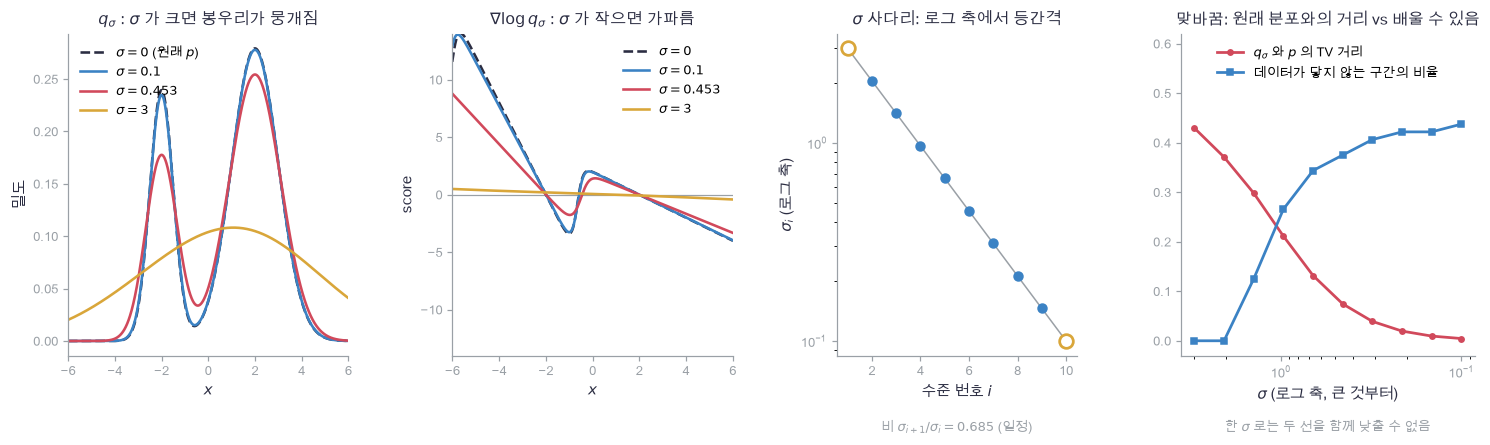

In [9]:
plot_sigma_ladder(ladder_x, [0.0, ladder[9], ladder[5], ladder[0]],
                  [ladder_p, ladder_pdfs[9], ladder_pdfs[5], ladder_pdfs[0]],
                  [mix_score_noisy(ladder_x, 0.0), ladder_scores[9], ladder_scores[5], ladder_scores[0]],
                  ladder, ladder_tv, ladder_empty)

🔍 **확인** · 왼쪽 두 패널에서 $\sigma$가 커질수록 두 봉우리 사이의 골이 메워지고 score가 완만해집니다. $\sigma=3$에서는 봉우리가 아예 하나로 보입니다. 셋째 패널의 사다리는 **로그 축에서 등간격**이고, 이웃한 두 수준의 비가 모두 $0.685$로 같습니다.

넷째 패널이 이 절의 요점입니다(가로 축은 큰 $\sigma$부터 왼쪽에서 오른쪽으로). 빨간 선(원래 분포와의 TV 거리)은 왼쪽 끝에서 크고, 파란 선(데이터가 닿지 않는 구간의 비율)은 오른쪽 끝에서 큽니다. 두 선이 서로 반대 방향이라 **한 $\sigma$만으로는 둘 다 만족할 수 없습니다.** 게다가 작은 $\sigma$에서 못 배우는 그 구간의 score는 크기가 8을 넘습니다(위 출력의 두 번째 줄). 배우지 못하는 곳에서 큰 화살표가 필요한 셈입니다. 32번의 학습 결과(봉우리 사이 RMS 오차 $\sigma=0.1$에서 $0.628$, $\sigma=1.0$에서 $0.022$)가 같은 이야기였습니다. 사다리는 큰 $\sigma$에서 시작해 작은 $\sigma$로 내려가며 두 끝을 잇습니다.

아래 구현은 사다리를 만드는 한 줄짜리 함수입니다. 검산에서는 비가 일정한지, 끝점이 맞는지, 손으로 계산할 수 있는 작은 경우가 맞는지 봅니다.

In [10]:
def sigma_ladder(sigma_max, sigma_min, levels):
    """잡음 수준의 기하 수열 σ_i = σ_max (σ_min/σ_max)^((i−1)/(L−1)), i = 1…L.
    sigma_max, sigma_min: 양수, levels: 2 이상의 정수 → (levels,) 내림차순 배열."""
    assert sigma_max > sigma_min > 0, "σ_max 는 σ_min 보다 크고 둘 다 양수여야 합니다"
    assert levels >= 2, "수준은 2개 이상이어야 합니다"
    return sigma_max * (sigma_min / sigma_max) ** (np.arange(levels) / (levels - 1))

In [11]:
# 쓰는 것: ladder (1절 사다리 셀)
hand_ladder = sigma_ladder(4.0, 1.0, 3)                              # 손계산: 비가 (1/4)^(1/2) = 1/2 이므로 4, 2, 1
np.testing.assert_allclose(hand_ladder, [4., 2., 1.])                # 검산: 손계산 4 → 2 → 1
check_ladder = sigma_ladder(3.0, 0.1, 10)
np.testing.assert_allclose(check_ladder, ladder)                      # 검산: 위 계산 셀의 사다리와 같음
ratios = check_ladder[1:] / check_ladder[:-1]                         # (9,): 이웃한 두 수준의 비
np.testing.assert_allclose(ratios, ratios[0])                         # 검산: 비가 모든 자리에서 같음 (기하 수열)
np.testing.assert_allclose([check_ladder[0], check_ladder[-1]], [3.0, 0.1])   # 검산: 끝점이 σ_max, σ_min
assert np.all(np.diff(check_ladder) < 0), "사다리는 큰 σ 에서 작은 σ 로 내려가야 합니다"
print("비 =", ratios[0].round(4), "= (0.1/3)^(1/9) =", round((0.1 / 3.0) ** (1 / 9), 4), "· 사다리 검산 통과")

비 = 0.6853 = (0.1/3)^(1/9) = 0.6853 · 사다리 검산 통과


### ✏️ 연습 1 · 잡음 사다리 한 줄

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

$\sigma_{\max}$에서 $\sigma_{\min}$까지 `levels`개를 기하 수열로 늘어놓는 한 줄을 채우세요. 지수 $\frac{i-1}{L-1}$은 `np.arange(levels) / (levels - 1)`입니다. 검사는 손계산 $4, 2, 1$과 1절 사다리, 그리고 비가 일정한지를 봅니다.

In [12]:
def exercise_sigma_ladder(sigma_max, sigma_min, levels):
    """연습 1: 잡음 수준의 기하 수열. sigma_max, sigma_min: 양수, levels: 정수 → (levels,)."""
    assert sigma_max > sigma_min > 0, "σ_max 는 σ_min 보다 크고 둘 다 양수여야 합니다"
    assert levels >= 2, "수준은 2개 이상이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: sigmas = σ_max × (σ_min/σ_max)^(arange(levels)/(levels−1))   (모양 (levels,))
    ### 힌트: 1절 sigma_ladder 의 한 줄입니다. ** 는 원소별 거듭제곱이라 배열 지수를 그대로 받습니다.
    raise NotImplementedError
    return sigmas

In [13]:
def check_sigma_ladder(candidate):
    """손계산 4 → 2 → 1, 1절 사다리, 비가 일정한지로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: ladder (1절 사다리 셀) · sigma_ladder (1절)
    hand = candidate(4.0, 1.0, 3)
    assert hand.shape == (3,), f"수준이 3개면 모양은 (3,)여야 하는데 {np.shape(hand)}입니다"
    np.testing.assert_allclose(hand, [4., 2., 1.])                    # 검산: 비가 1/2 인 손계산
    np.testing.assert_allclose(candidate(3.0, 0.1, 10), ladder)       # 검산: 1절 그림의 사다리
    np.testing.assert_allclose(candidate(2.0, 0.5, 7), sigma_ladder(2.0, 0.5, 7))   # 검산: 본문 함수와 같음
    got = candidate(10.0, 0.01, 6)
    np.testing.assert_allclose(got[1:] / got[:-1], (0.01 / 10.0) ** (1 / 5))        # 검산: 이웃한 두 수준의 비가 일정
    print("잡음 사다리: 손계산·본문 함수와 일치합니다.")

run_check(check_sigma_ladder, exercise_sigma_ladder, hint="sigmas = sigma_max * (sigma_min / sigma_max) ** (np.arange(levels) / (levels - 1))")

☐ exercise_sigma_ladder: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: sigmas = sigma_max * (sigma_min / sigma_max) ** (np.arange(levels) / (levels - 1))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
sigmas = sigma_max * (sigma_min / sigma_max) ** (np.arange(levels) / (levels - 1))
```

</details>

## 🔑 2. Langevin dynamics: 잡음을 섞은 오르막

**이 절에서 가져갈 것:** $x\leftarrow x+\frac{\alpha}{2}s(x)+\sqrt\alpha\,z$를 오래 반복하면 점들이 $p$를 따라 퍼집니다. 걸음 크기 $\alpha$가 크면 빠르지만 치우침(편향)이 남고, 작으면 정확하지만 느립니다. 그리고 그 수준에 맞는 걸음 크기($\alpha\propto\sigma^2$, 4절)로 걸으면 작은 $\sigma$에서는 정해진 걸음 수 안에 옆 봉우리에 닿지 못합니다.

score를 알면 점을 어디로 옮길지 압니다. 그런데 화살표만 따라가면 모두 봉우리 꼭대기에 모입니다(32번 5절의 오르막). 샘플은 꼭대기 하나가 아니라 밀도만큼 흩어져야 하므로 걸음마다 잡음을 섞습니다.

> **용어**
>
> - **Langevin dynamics**: $x_{t+1}=x_t+\frac{\alpha}{2}s(x_t)+\sqrt\alpha\,z_t$, $z_t\sim\mathcal N(0,I)$. 오르막 $\alpha/2$와 잡음 $\sqrt\alpha$의 비율이 이렇게 맞을 때, $\alpha\to0$·반복 $\to\infty$의 극한에서 점의 분포가 $p$가 됩니다.
> - **정상 분포(stationary distribution)**: 반복을 계속해도 더 이상 바뀌지 않는 점들의 분포. $\alpha>0$이면 $p$가 아니라 조금 다른 분포로 갑니다. 그 차이가 **편향**입니다.

$$x_{t+1}=x_t+\frac{\alpha}{2}s(x_t)+\sqrt{\alpha}\,z_t,\qquad z_t\sim\mathcal N(0,I).$$

$x_t$가 입자 $(M,)$이면 $s(x_t)$와 $z_t$도 $(M,)$이고 모든 입자가 한 줄로 움직입니다. 2차원이면 $(M,2)$입니다.

손계산 $p=\mathcal N(0,1)$, $s(x)=-x$, $x=1$, $\alpha=0.4$, $z=0.5$: $1+0.2\times(-1)+\sqrt{0.4}\times0.5=1-0.2+0.3162=1.1162$.

같은 표준정규에서는 **편향을 닫힌식으로 쓸 수 있습니다.** 한 걸음은 $x_{t+1}=(1-\frac{\alpha}{2})x_t+\sqrt\alpha\,z_t$이므로 분산은 $v=(1-\frac{\alpha}{2})^2v+\alpha$를 만족합니다. 풀면
$$v=\frac{\alpha}{1-(1-\frac{\alpha}{2})^2}=\frac{1}{1-\frac{\alpha}{4}}.$$
$\alpha=0.4$면 $v=1.111$로 참값 1보다 11% 큽니다. $\alpha$가 작을수록 1에 가까워지지만 그만큼 한 걸음이 짧아 오래 걸립니다. 이 식이 아래 검산의 잣대입니다.

아래는 정확한 score로 2차원 혼합에서 걸어 본 경로와, 1차원에서 $\alpha$를 셋으로 바꾼 히스토그램입니다.

> **코드**
>
> - `np.histogram(v, edges)[0]`: 구간 경계 `edges`로 나눈 개수 `(len(edges) − 1,)`. 입자 수로 나누면 구간 확률입니다.
> - `np.meshgrid(xs, ys)`: 가로 격자 `xs`와 세로 격자 `ys`에서 모든 $(x, y)$ 쌍의 좌표 두 배열. `np.column_stack([xx.ravel(), yy.ravel()])`로 펴면 `(점 수, 2)`.

In [14]:
# 쓰는 것: mix2_score_noisy, mix2_logpdf (📎 혼합 셀)
walk_alpha = 0.1
walk_rng = np.random.default_rng(3302)
walk_X = walk_rng.uniform(-5, 5, size=(2500, 2))                     # (2500, 2): 넓게 뿌린 입자
walk_X[:4] = np.array([[-4., -3.], [4., 4.], [-3., 4.], [3., -3.]])   # 경로를 볼 네 개
walk_path = [walk_X[:4].copy()]
for step in range(800):
    walk_X = walk_X + walk_alpha / 2 * mix2_score_noisy(walk_X, 0.0) + np.sqrt(walk_alpha) * walk_rng.normal(size=walk_X.shape)
    if step < 150:
        walk_path.append(walk_X[:4].copy())
walk_path = np.array(walk_path)                                      # (151, 4, 2): 처음 150 걸음의 경로
dense_xx, dense_yy = np.meshgrid(np.linspace(-6, 6, 121), np.linspace(-5, 6, 111))   # (111, 121) 둘: 등고선 격자
dense_X = np.column_stack([dense_xx.ravel(), dense_yy.ravel()])      # (13431, 2)
dense_pdf = np.exp(mix2_logpdf(dense_X)).reshape(dense_xx.shape)     # (111, 121): 2차원 혼합의 밀도
print("2차원 Langevin 800 걸음 뒤 평균", walk_X.mean(axis=0).round(3), "(닫힌식 [0.4 0.6])")

2차원 Langevin 800 걸음 뒤 평균 [0.346 0.566] (닫힌식 [0.4 0.6])


In [15]:
# 쓰는 것: mix_score_noisy, mix_logpdf (📎 혼합 셀)
alpha_values = [0.01, 0.1, 0.6]
alpha_edges = np.linspace(-6, 6, 49)                                 # (49,): 히스토그램 구간 경계 (폭 0.25)
alpha_centers = 0.5 * (alpha_edges[1:] + alpha_edges[:-1])           # (48,)
alpha_density = np.exp(mix_logpdf(alpha_centers)) * 0.25             # (48,): 구간별 p 의 확률 (밀도 × 폭)
alpha_hists, alpha_tv = [], []
for alpha in alpha_values:
    alpha_rng = np.random.default_rng(3303)
    particles = alpha_rng.uniform(-6, 6, size=3000)                  # (3000,): 같은 출발
    for step in range(1000):
        particles = particles + alpha / 2 * mix_score_noisy(particles, 0.0) + np.sqrt(alpha) * alpha_rng.normal(size=3000)
    hist = np.histogram(particles, alpha_edges)[0] / 3000            # (48,): 구간별 입자 비율
    alpha_hists.append(hist)
    alpha_tv.append(0.5 * np.abs(hist - alpha_density).sum())
print("α =", alpha_values, "· 1,000 걸음 뒤 TV 거리:", np.round(alpha_tv, 3))

α = [0.01, 0.1, 0.6] · 1,000 걸음 뒤 TV 거리: [0.105 0.045 0.18 ]


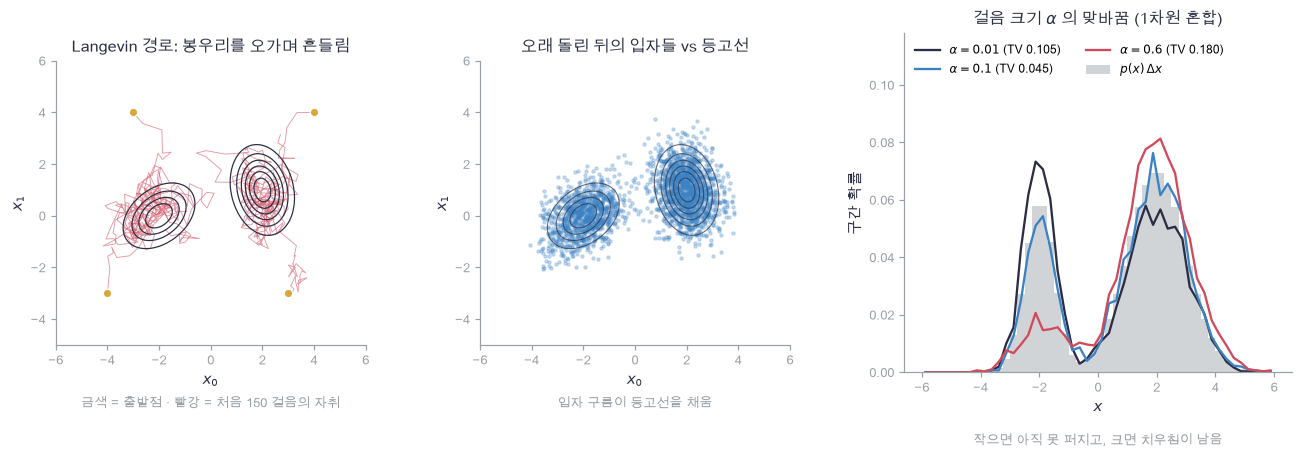

In [16]:
plot_langevin_walk(walk_path, walk_X, dense_xx, dense_yy, dense_pdf, alpha_values,
                   alpha_centers, alpha_hists, alpha_density, alpha_tv)

🔍 **확인** · 왼쪽 경로는 멀리서 출발해도 등고선 안으로 들어와 봉우리 주변을 흔들립니다. 가운데는 800걸음 뒤 2,500개 입자가 등고선을 고르게 채운 모습입니다. 오른쪽에서 $\alpha=0.01$(TV가 가장 큼)은 1,000걸음으로도 아직 다 퍼지지 못했고, $\alpha=0.6$은 봉우리가 뭉개져 치우침이 보입니다. $\alpha=0.1$이 셋 중 가장 낫습니다.

아래 구현은 한 걸음 함수와 반복 함수입니다. 검산은 손계산, 표준정규에서의 닫힌식 편향 $1/(1-\alpha/4)$, $p$에서 출발했을 때 머무는지(정상성), 그리고 **그 수준에 맞는 걸음 크기로 걸으면 작은 $\sigma$에서는 옆 봉우리에 닿지 못한다**는 것을 봅니다. 마지막 검산 셀은 같은 $\sigma=0.1$에서 걸음 크기만 $\alpha=0.1$로 되돌려, 갇힘의 원인이 장벽의 깊이가 아니라 걸음 크기임을 대조합니다.

In [17]:
def langevin_step(x, score, alpha, z):
    """Langevin 한 걸음 x + (α/2) s + √α z. score 와 잡음 z 를 값으로 받습니다.
    x, score, z: 같은 모양, alpha: 숫자 → 같은 모양."""
    return x + alpha / 2 * score + np.sqrt(alpha) * z


def langevin(score_fn, x0, alpha, steps, rng):
    """정해진 σ 하나에서 Langevin 을 steps 번 반복. score_fn: x → 같은 모양의 score.
    x0: (M,) 또는 (M, D) → 마지막 위치 (같은 모양)."""
    x = x0.copy()                                                    # 출발점을 바꾸지 않도록 복사
    for step in range(steps):
        x = langevin_step(x, score_fn(x), alpha, rng.normal(size=x.shape))
    return x

In [18]:
# 쓰는 것: langevin_step, langevin (2절)
np.testing.assert_allclose(langevin_step(1.0, -1.0, 0.4, 0.5), 1.1162, atol=1e-4)   # 검산: 손계산 1 − 0.2 + 0.3162


def normal_score(x):
    """표준정규 N(0, 1) 의 score s(x) = −x. 편향 검산에 쓰는 가장 단순한 분포입니다."""
    return -x


bias_rng = np.random.default_rng(3304)
bias_measured, bias_closed = [], []
for alpha in [0.1, 0.4, 1.0]:
    final = langevin(normal_score, np.zeros(20000), alpha, 400, bias_rng)   # (20000,): 400 걸음 뒤
    bias_measured.append(float(final.var()))
    bias_closed.append(1 / (1 - alpha / 4))
np.testing.assert_allclose(bias_measured, bias_closed, rtol=0.02)    # 검산: 정상 분산 = 1/(1 − α/4)
print("α = 0.1, 0.4, 1.0 의 정상 분산: 실험", np.round(bias_measured, 4), "· 닫힌식", np.round(bias_closed, 4))

α = 0.1, 0.4, 1.0 의 정상 분산: 실험 [1.0105 1.0984 1.3304] · 닫힌식 [1.0256 1.1111 1.3333]


In [19]:
# 쓰는 것: mix_score_noisy, mix_sample (📎 혼합 셀) · langevin (2절) · walk_alpha (2절 경로 셀) · alpha_edges, alpha_density (2절 α 셀)
stay_rng = np.random.default_rng(3305)


def p_score(x):
    """원래 혼합 p 의 score (σ = 0 인 q_σ). x: (M,) → (M,)."""
    return mix_score_noisy(x, 0.0)


stay_x = langevin(p_score, mix_sample(4000, stay_rng), walk_alpha, 300, stay_rng)   # p 의 샘플로 출발
stay_tv = 0.5 * np.abs(np.histogram(stay_x, alpha_edges)[0] / 4000 - alpha_density).sum()
assert stay_tv < 0.06, "p 의 샘플로 시작하면 300 걸음 뒤에도 p 근처(TV < 0.06)에 있어야 합니다"
trap_fractions = []
for sigma in [0.1, 1.0]:                                             # 걸음 크기는 score 크기에 맞춰 σ² 에 비례 (4절에서 다시 봅니다)

    def level_score(x):
        """이번 수준 σ 의 q_σ score. 반복문 변수 sigma 를 그대로 씁니다."""
        return mix_score_noisy(x, sigma)

    stuck = langevin(level_score, np.full(4000, -2.0), 0.1 * sigma ** 2, 300, stay_rng)   # 왼쪽 봉우리에서 출발
    trap_fractions.append(float(np.mean(stuck > 0)))
assert trap_fractions[0] < 0.02, "σ = 0.1 에서는 300 걸음 동안 오른쪽 봉우리로 거의 넘어가지 못해야 합니다"
assert trap_fractions[1] > 0.3, "σ = 1.0 에서는 상당수가 오른쪽 봉우리로 넘어가야 합니다"
print("정상성 TV 거리", round(stay_tv, 4), "· 왼쪽 봉우리에서 출발해 오른쪽으로 넘어간 비율: σ=0.1 →",
      round(trap_fractions[0], 3), "· σ=1.0 →", round(trap_fractions[1], 3))

정상성 TV 거리 0.0375 · 왼쪽 봉우리에서 출발해 오른쪽으로 넘어간 비율: σ=0.1 → 0.0 · σ=1.0 → 0.601


In [20]:
# 쓰는 것: mix_score_noisy, mix_logpdf (📎 혼합 셀) · langevin (2절) · walk_alpha (2절 경로 셀)
same_rng = np.random.default_rng(3313)


def small_sigma_score(x):
    """위 검산과 같은 수준 σ = 0.1 의 q_σ score. x: (M,) → (M,)."""
    return mix_score_noisy(x, 0.1)


same_step = langevin(small_sigma_score, np.full(4000, -2.0), walk_alpha, 300, same_rng)   # α 만 0.1 로 되돌림
same_fraction = float(np.mean(same_step > 0))
assert same_fraction > 0.3, "σ = 0.1 이어도 α = 0.1 로 걸으면 상당수가 오른쪽 봉우리로 넘어가야 합니다"
barrier = float(mix_logpdf(np.array([2.0]))[0] - mix_logpdf(np.array([0.0]))[0])   # 오른쪽 봉우리와 골의 log p 차이
print("σ = 0.1 에서 α 만 0.1 로 되돌린 300 걸음: 오른쪽으로 넘어간 비율", round(same_fraction, 3),
      "· 봉우리와 골의 log p 차이", round(barrier, 2), "nat")

σ = 0.1 에서 α 만 0.1 로 되돌린 300 걸음: 오른쪽으로 넘어간 비율 0.453 · 봉우리와 골의 log p 차이 2.0 nat


🔍 **확인** · 손계산 한 걸음이 맞고, 표준정규에서 잰 정상 분산이 닫힌식 $1/(1-\alpha/4)$와 2% 안에서 같습니다. $\alpha=1.0$이면 분산이 참값보다 33% 크다는 것을 실험이 그대로 보여 줍니다. $p$의 샘플로 시작하면 300걸음 뒤에도 $p$에 머뭅니다.

마지막 두 셀이 이 노트북의 핵심 동기입니다. 입자를 **모두 왼쪽 봉우리에 모아 두고** 그 수준에 맞는 걸음 크기($\alpha=0.1\,\sigma^2$, 4절의 $\alpha_i\propto\sigma_i^2$)로 걸으면, $\sigma=0.1$에서는 300걸음 동안 오른쪽으로 넘어간 입자가 사실상 없고 $\sigma=1.0$에서는 절반 넘게 넘어갑니다. 원인은 장벽이 깊어서가 아닙니다. 봉우리와 골의 차이는 $\log p(2)-\log p(0)=2.00$ nat뿐이고, 같은 $\sigma=0.1$에서 걸음 크기만 $\alpha=0.1$로 되돌리면 0.45쯤이 넘어갑니다(대조 셀). $\alpha=0.1\,\sigma^2$은 $\sigma=0.1$에서 $\alpha=0.001$이라, 같은 300걸음이라도 총 확산 거리가 100배 짧아 봉우리 사이를 덮지 못하는 것입니다. 큰 $\sigma$에서 비율을 정하고 작은 $\sigma$로 내려오는 것이 4절의 annealed Langevin입니다.

### ✏️ 연습 2 · Langevin 한 걸음

입자 `x` `(M,)`, 그 자리의 score 값 `score` `(M,)`, 걸음 크기 `alpha`, 표준정규 잡음 `z` `(M,)`에서 한 걸음 $x+\frac{\alpha}{2}s+\sqrt\alpha\,z$를 만드는 한 줄을 채우세요. 검사는 2절 손계산($1.1162$)과 $z=0$일 때의 오르막, 본문 `langevin_step`으로 합니다.

In [21]:
def exercise_langevin_step(x, score, alpha, z):
    """연습 2: Langevin 한 걸음. x, score, z: (M,), alpha: 숫자 → x_next: (M,)."""
    assert x.shape == score.shape, "입자와 score 는 같은 모양이어야 합니다"
    assert x.shape == z.shape, "입자와 잡음은 같은 모양이어야 합니다"
    assert alpha > 0, "걸음 크기는 양수여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: x_next = x + (alpha/2) × score + √alpha × z   (모양 (M,))
    ### 힌트: 2절 langevin_step 의 한 줄입니다. √ 는 np.sqrt(alpha) 입니다.
    raise NotImplementedError
    return x_next

In [22]:
def check_langevin_step(candidate):
    """2절 손계산(1.1162), z = 0 이면 오르막, 본문 langevin_step 으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: langevin_step (2절) · mix_score_noisy (📎 혼합 셀)
    np.testing.assert_allclose(candidate(np.array([1.]), np.array([-1.]), 0.4, np.array([0.5])), [1.1162], atol=1e-4)   # 검산: 손계산
    x_c = np.random.default_rng(3311).uniform(-4, 4, size=5)
    s_c = mix_score_noisy(x_c, 0.3)
    np.testing.assert_allclose(candidate(x_c, s_c, 0.2, np.zeros(5)), x_c + 0.1 * s_c)          # 검산: z = 0 이면 오르막 한 걸음
    z_c = np.random.default_rng(3312).normal(size=5)
    np.testing.assert_allclose(candidate(x_c, s_c, 0.2, z_c), langevin_step(x_c, s_c, 0.2, z_c))   # 검산: 본문 함수와 같음
    print("Langevin 한 걸음: 손계산·오르막·langevin_step 과 일치합니다.")

run_check(check_langevin_step, exercise_langevin_step, hint="x_next = x + alpha / 2 * score + np.sqrt(alpha) * z")

☐ exercise_langevin_step: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: x_next = x + alpha / 2 * score + np.sqrt(alpha) * z


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
x_next = x + alpha / 2 * score + np.sqrt(alpha) * z
```

</details>

## 🔑 3. $\sigma$를 입력으로 받는 하나의 score 신경망

**이 절에서 가져갈 것:** 수준마다 모델을 따로 두는 대신 $\sigma$를 **입력에 이어 붙여** 하나의 신경망이 모든 수준을 배웁니다. 출력은 $s_\theta(x,\sigma)=U_\theta(x,\log\sigma)/\sigma$로 두고, 손실에는 $\sigma^2$을 곱합니다. 타깃 $-\epsilon/\sigma$의 크기가 $1/\sigma$라 가중 전 손실이 $1/\sigma^2$ 규모인데, 이 가중이 모든 수준의 손실을 비슷한 크기로 맞춥니다.

사다리가 10개면 모델도 10개일까요? 그러면 파라미터가 10배가 되고, 이웃한 수준끼리 거의 같은 답을 내야 한다는 사실을 쓰지 못합니다. 대신 모델에게 "지금 몇 번째 수준인가"를 알려 주고 하나로 배우게 합니다.

> **용어**
>
> - **NCSN(noise conditional score network)**: 잡음 크기 $\sigma$를 조건으로 받는 score 신경망. 입력이 $(x,\sigma)$이고 출력이 그 수준의 score입니다 (Song·Ermon 2019).
> - **조건 입력(conditioning)**: 예측에 필요한 곁정보를 입력 벡터에 이어 붙이는 것. 여기서는 $\log\sigma$ 한 열입니다. 수준이 기하 수열이라 로그 축에서 등간격이므로 로그를 씁니다(09번 4절의 sinusoidal 표를 써도 됩니다).
> - **가중 손실(weighted loss)**: 여러 항을 더할 때 항마다 곱하는 계수 $\lambda(\sigma_i)$. 어떤 항이 다른 항을 덮지 않게 크기를 맞춥니다.

모델은 2층 tanh MLP에 출력층 하나를 더한 것입니다. $\tilde X$가 $(N,D)$, $\log\sigma$가 $(N,1)$이면 이어 붙인 입력은 $(N,D+1)$입니다.

$$H_1=\tanh([\tilde X,\log\sigma]W_1+b_1),\quad H_2=\tanh(H_1W_2+b_2),\quad U=H_2W_3+b_3,\quad
s_\theta(\tilde x,\sigma)=\frac{U}{\sigma}.$$

$W_1$은 $(D+1,H)$, $W_2$는 $(H,H)$, $W_3$은 $(H,D)$이고 $U$와 $s_\theta$는 $(N,D)$입니다. $\sigma$로 나누는 것이 이 모델의 핵심입니다. 32번에서 DSM의 타깃이 $-\epsilon/\sigma$였으므로 $\sigma s_\theta\approx-\epsilon$이 되어야 하고, $\epsilon$은 표준정규라 크기가 1입니다. 즉 **신경망이 내야 할 $U$는 어느 수준에서나 크기 1 근처**입니다.

손실은 수준마다 32번의 DSM 손실에 $\lambda(\sigma_i)=\sigma_i^2$을 곱해 더한 것입니다.

$$J(\theta)=\frac1L\sum_{i=1}^{L}\sigma_i^2\;\mathbb E\left\|s_\theta(\tilde x,\sigma_i)+\frac{\epsilon}{\sigma_i}\right\|^2
=\frac1L\sum_{i=1}^{L}\mathbb E\left\|\sigma_i s_\theta(\tilde x,\sigma_i)+\epsilon\right\|^2,\qquad
\frac{\partial J}{\partial S}=\frac{2\sigma}{N}\left(\sigma S+\epsilon\right).$$

$\sigma$가 점마다 다르므로 코드에서는 $(N,1)$로 세워 브로드캐스팅합니다. 왜 하필 $\sigma^2$일까요. 타깃 $-\epsilon/\sigma$의 제곱 평균은 정확히 $1/\sigma^2$이고, 최적 score는 그 조건부 평균이라 언제나 그보다 작습니다($\sigma$가 데이터 규모보다 클 때만 크기가 $1/\sigma$에 가깝습니다. 아래 그림 왼쪽에서 두 선의 간격을 보세요). 가중 전 손실은 타깃의 제곱 평균에서 score의 제곱 평균을 뺀 값이라 $1/\sigma^2$ 규모고, **가장 작은 수준 하나가 합을 독차지**합니다. $\sigma^2$을 곱하면 모든 항이 $\|\epsilon\|^2$ 규모, 즉 $D$ 근처로 맞춰집니다.

손계산 $N=2$, $D=1$: $S=(0.5,-1)$, $\epsilon=(1,-1)$, $\sigma=(0.5,2)$이면 $\sigma S+\epsilon=(1.25,-3)$, $J=(1.5625+9)/2=5.28125$, $\partial J/\partial S=(2\cdot0.5\cdot1.25/2,\ 2\cdot2\cdot(-3)/2)=(0.625,-6)$.

아래 계산 셀은 **닫힌식 최적 score**를 넣었을 때 수준마다 손실이 얼마인지를 가중 전후로 잽니다. 신경망 없이 재는 값이라 "무엇이 학습을 독차지하는가"를 그대로 보여 줍니다.

In [23]:
# 쓰는 것: ladder (1절 사다리 셀) · mix_sample, mix_score_noisy (📎 혼합 셀)
weight_rng = np.random.default_rng(3306)
weight_clean = mix_sample(20000, weight_rng)                         # (20000,): 깨끗한 데이터
weight_eps = weight_rng.normal(size=20000)                           # (20000,): 잡음 ε
weight_plain, weight_scaled = [], []                                 # 수준마다 가중 전·후 손실
weight_size, weight_target = [], []                                  # 최적 score 의 크기(RMS)와 타깃의 제곱 평균
for sigma in ladder:
    best = mix_score_noisy(weight_clean + sigma * weight_eps, sigma)  # (20000,): 그 수준의 최적 score (닫힌식)
    weight_plain.append(float(np.mean((best + weight_eps / sigma) ** 2)))     # 32번의 DSM 손실 E‖s + ε/σ‖²
    weight_scaled.append(float(np.mean((sigma * best + weight_eps) ** 2)))    # σ² 을 곱한 뒤 E‖σs + ε‖²
    weight_size.append(float(np.sqrt(np.mean(best ** 2))))            # √E[s²]: 그 수준에서 score 가 얼마나 큰가
    weight_target.append(float(np.mean((weight_eps / sigma) ** 2)))   # E[(ε/σ)²] ≈ 1/σ²: 타깃의 제곱 평균
print("가중 전 손실:", np.round(weight_plain, 3))
print("가중 후 손실:", np.round(weight_scaled, 3), "· 가장 큰 항과 가장 작은 항의 비:",
      round(max(weight_plain) / min(weight_plain), 1), "→", round(max(weight_scaled) / min(weight_scaled), 1))

가중 전 손실: [ 0.034  0.11   0.297  0.701  1.613  3.815  8.922 20.227 44.612 96.734]
가중 후 손실: [0.308 0.466 0.59  0.654 0.706 0.784 0.861 0.917 0.95  0.967] · 가장 큰 항과 가장 작은 항의 비: 2828.4 → 3.1


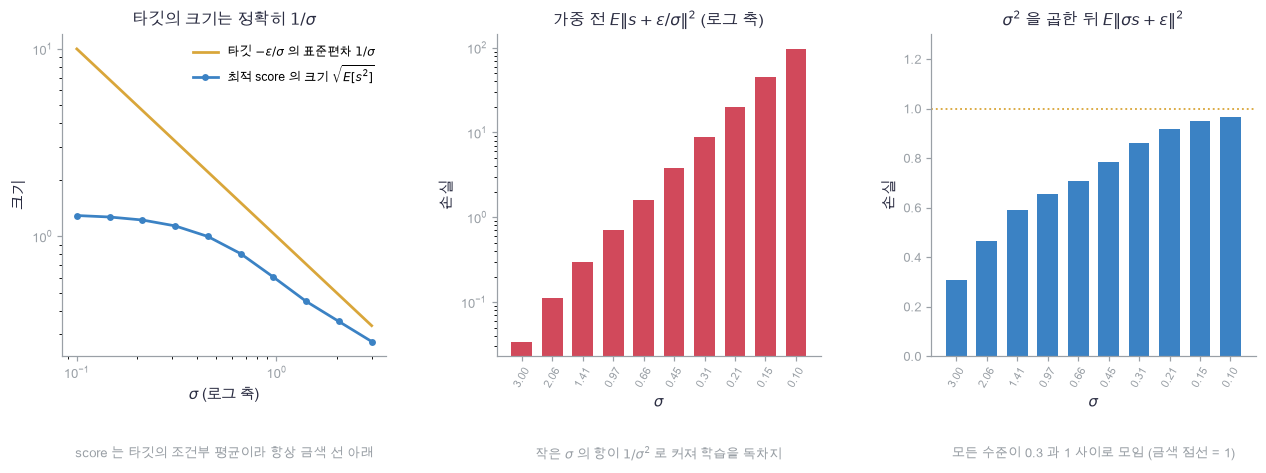

In [24]:
plot_loss_weighting(ladder, weight_size, weight_plain, weight_scaled)

🔍 **확인** · 왼쪽에서 금색 선(타깃 $-\epsilon/\sigma$의 표준편차 $1/\sigma$)과 파란 선(그 수준에서 최적 score의 크기)이 함께 커집니다. score는 타깃의 조건부 평균이라 언제나 금색 선 아래입니다. 가운데(가중 전)는 세로 축이 로그인데도 막대 길이가 크게 다릅니다. 가장 작은 수준의 손실이 가장 큰 수준의 3,000배쯤이라, 그대로 더하면 학습이 작은 $\sigma$ 하나만 보게 됩니다. 오른쪽에서 $\sigma^2$을 곱하면 모든 수준이 0.3과 1 사이로 모입니다. 큰 $\sigma$의 값이 조금 작은 것은 $\tilde x\approx\sigma\epsilon$이라 잡음을 거의 알아맞힐 수 있기 때문입니다.

아래 구현은 조건 입력을 만드는 함수, 모델의 forward·backward, 가중 손실, Adam 갱신, 학습 루프입니다. 04번 6절의 Adam을 그대로 쓰고, 01b번 4절의 미니배치 학습 루프와 같되 에폭 대신 스텝마다 새로 뽑습니다.

> **코드**
>
> - `np.reshape(sigma, (-1, 1))`: 숫자 하나든 `(N,)` 배열이든 `(N, 1)`로 세웁니다. `(N, D)` 배열과 브로드캐스팅하려고 이렇게 둡니다.
> - `np.concatenate([X, feature], axis=1)`: 열 방향으로 이어 붙이기. `(N, D)`와 `(N, 1)`이 `(N, D+1)`이 됩니다.
> - `sigmas[rng.integers(0, len(sigmas), batch)]`: 배치의 표본마다 수준 하나를 고르게 뽑습니다.
> - `{key: (np.zeros_like(value), np.zeros_like(value)) for key, value in p.items()}`: 파라미터마다 Adam 상태 (m, v)를 0으로 만든 사전 (05번 5절).

In [25]:
def sigma_feature(sigma):
    """조건 입력 φ(σ) = log σ 한 열. 수준이 기하 수열이라 로그 축에서 등간격입니다.
    sigma: 숫자 또는 (N,) → (N, 1)."""
    return np.log(np.reshape(sigma, (-1, 1)))


def init_ncsn(D, hidden, seed):
    """NCSN 파라미터: W1 (D+1, hidden), W2 (hidden, hidden), W3 (hidden, D)와 편향. 32번 4절 `init_score_model` 과 같은 초기화(표준편차 1/√입력)."""
    rng_init = np.random.default_rng(seed)
    inputs = D + 1                                                   # 좌표 D 개 + log σ 한 열
    return {"W1": rng_init.normal(size=(inputs, hidden)) / np.sqrt(inputs), "b1": np.zeros(hidden),
            "W2": rng_init.normal(size=(hidden, hidden)) / np.sqrt(hidden), "b2": np.zeros(hidden),
            "W3": rng_init.normal(size=(hidden, D)) / np.sqrt(hidden), "b3": np.zeros(D)}

In [26]:
def ncsn_forward(X, sigma, p):
    """NCSN forward: H1 = tanh([X, log σ] W1 + b1), H2 = tanh(H1 W2 + b2), U = H2 W3 + b3, s = U/σ.
    X: (N, D), sigma: (N,) → (S: (N, D), cache: (입력, H1, H2, σ열))."""
    column = np.reshape(sigma, (-1, 1))                              # (N, 1) 또는 (1, 1): σ 를 세움
    inputs = np.concatenate([X, sigma_feature(sigma)], axis=1)       # (N, D+1): 좌표에 log σ 를 이어 붙임
    H1 = np.tanh(inputs @ p["W1"] + p["b1"])                         # (N, hidden)
    H2 = np.tanh(H1 @ p["W2"] + p["b2"])                             # (N, hidden)
    return (H2 @ p["W3"] + p["b3"]) / column, (inputs, H1, H2, column)


def ncsn_backward(dS, cache, p):
    """NCSN backward (03번 5절의 두 층을 세 층으로): dU = dS/σ 부터 거슬러 올라갑니다.
    dS: (N, D), cache: ncsn_forward 의 것 → grads: p 와 같은 키의 사전."""
    inputs, H1, H2, column = cache
    dU = dS / column                                                 # (N, D): s = U/σ 의 미분
    dH2 = dU @ p["W3"].T                                             # (N, hidden)
    dZ2 = dH2 * (1 - H2 ** 2)                                        # tanh 의 도함수 1 − H²
    dH1 = dZ2 @ p["W2"].T
    dZ1 = dH1 * (1 - H1 ** 2)
    return {"W1": inputs.T @ dZ1, "b1": dZ1.sum(axis=0), "W2": H1.T @ dZ2, "b2": dZ2.sum(axis=0),
            "W3": H2.T @ dU, "b3": dU.sum(axis=0)}

In [27]:
def ncsn_loss(S, eps, sigma):
    """σ² 가중 DSM 손실 J = mean_n ‖σ_n S_n + ε_n‖² 와 출력 기울기 ∂J/∂S = 2σ(σS + ε)/N.
    S, eps: (N, D), sigma: 숫자 또는 (N,) → (J: 숫자, dS: (N, D))."""
    column = np.reshape(sigma, (-1, 1))                              # (N, 1): 표본마다 다른 σ
    residual = column * S + eps                                      # (N, D): σ s_θ − (−ε), 즉 예측 − 타깃에 σ 를 곱한 것
    return float(np.mean(np.sum(residual ** 2, axis=1))), 2 * column * residual / len(S)


def adam_step(p, grads, state, step, lr):
    """Adam 갱신 (04번 6절)을 파라미터 사전의 모든 배열에. p 를 제자리에서 바꾸고 state 의 (m, v)를 갱신합니다."""
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]                               # 1차 모멘트
        v = 0.999 * v + 0.001 * grads[key] ** 2                      # 2차 모멘트
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)   # 편향 보정 뒤 갱신
        state[key] = (m, v)

In [28]:
def train_ncsn(X, sigmas, steps, seed, batch=512, hidden=128, lr=2e-3):
    """NCSN 학습: 스텝마다 미니배치를 뽑고 표본마다 수준 σ_i 를 고르게 뽑아 x̃ = x + σ_i ε 을 만든 뒤 Adam 한 걸음.
    학습률은 마지막에 1/10 이 되게 줄입니다. X: (N, D) → (p: 파라미터 사전, history: (steps,))."""
    p = init_ncsn(X.shape[1], hidden, seed)
    state = {key: (np.zeros_like(value), np.zeros_like(value)) for key, value in p.items()}   # Adam 상태 (m, v)
    rng_train = np.random.default_rng(seed + 1)
    history = []
    for step in range(1, steps + 1):
        X_batch = X[rng_train.choice(len(X), batch, replace=False)]  # (batch, D): 미니배치
        sigma_batch = sigmas[rng_train.integers(0, len(sigmas), batch)]   # (batch,): 표본마다 수준 하나
        eps = rng_train.normal(size=X_batch.shape)                   # (batch, D): 스텝마다 새 잡음
        S, cache = ncsn_forward(X_batch + sigma_batch[:, None] * eps, sigma_batch, p)
        loss, dS = ncsn_loss(S, eps, sigma_batch)
        adam_step(p, ncsn_backward(dS, cache, p), state, step, lr * 0.1 ** (step / steps))
        history.append(loss)
    return p, np.array(history)

In [29]:
# 쓰는 것: ladder (1절 사다리 셀) · init_ncsn (3절)
probe_rng = np.random.default_rng(3307)
probe_p = init_ncsn(2, 8, 4)                                         # 작은 2차원 모델 (은닉 8)
probe_X = probe_rng.normal(size=(5, 2))                              # (5, 2): 검사용 잡음 낀 입력
probe_eps = probe_rng.normal(size=(5, 2))                            # (5, 2): 검사용 잡음
probe_sigma = ladder[probe_rng.integers(0, 10, 5)]                   # (5,): 표본마다 다른 수준
probe_S, probe_cache = ncsn_forward(probe_X, probe_sigma, probe_p)
probe_loss, probe_dS = ncsn_loss(probe_S, probe_eps, probe_sigma)
probe_grads = ncsn_backward(probe_dS, probe_cache, probe_p)


def ncsn_scalar():
    """검사기용: 현재 파라미터의 σ² 가중 손실 (같은 입력·잡음·σ)."""
    return ncsn_loss(ncsn_forward(probe_X, probe_sigma, probe_p)[0], probe_eps, probe_sigma)[0]


ncsn_errors = {key: rel_error(probe_grads[key], numerical_gradient(ncsn_scalar, value)) for key, value in probe_p.items()}
assert max(ncsn_errors.values()) < 1e-6, "여섯 파라미터의 기울기가 중심차분과 1e−6 안에서 같아야 합니다"
print("NCSN gradcheck 최대 상대오차:", max(ncsn_errors.values()))

NCSN gradcheck 최대 상대오차: 8.524878605763777e-10


In [30]:
# 쓰는 것: ladder (1절 사다리 셀) · weight_plain, weight_size, weight_target (3절 가중 셀)
hand_S = np.array([[0.5], [-1.]])                                    # (2, 1): 손계산용 예측
hand_eps = np.array([[1.], [-1.]])                                   # (2, 1): 손계산용 잡음
hand_loss, hand_dS = ncsn_loss(hand_S, hand_eps, np.array([0.5, 2.0]))
np.testing.assert_allclose(hand_loss, 5.28125)                       # 검산: 손계산 (1.25² + 3²)/2
np.testing.assert_allclose(hand_dS, [[0.625], [-6.]])                # 검산: 손계산 2σ(σS + ε)/N
same_loss, _ = ncsn_loss(hand_S, hand_eps, 0.5)                      # σ 를 둘 다 0.5 로
np.testing.assert_allclose(same_loss, 0.5 ** 2 * 7.625)              # 검산: 32번 4절의 가중 전 손실 7.625 의 σ² 배
np.testing.assert_allclose(weight_plain, np.array(weight_target) - np.array(weight_size) ** 2, rtol=0.03)   # 검산: 가중 전 손실 = 타깃의 제곱 평균 − 최적 score 크기² (조건부 평균이 남기는 잔차)
print("손계산 손실", hand_loss, "· 기울기", hand_dS.ravel(), "· σ² 가중 관계 확인 (32번 4절의 7.625 × 0.25 =", 0.25 * 7.625, ")")
print("최적 score 의 크기 (RMS):", np.round(weight_size, 3), "· 모두 1/σ =", np.round(1 / ladder, 2), "아래")

손계산 손실 5.28125 · 기울기 [ 0.625 -6.   ] · σ² 가중 관계 확인 (32번 4절의 7.625 × 0.25 = 1.90625 )
최적 score 의 크기 (RMS): [0.274 0.351 0.449 0.606 0.808 0.997 1.136 1.221 1.267 1.29 ] · 모두 1/σ = [ 0.33  0.49  0.71  1.04  1.51  2.21  3.22  4.7   6.85 10.  ] 아래


🔍 **확인** · 여섯 파라미터 모두 중심차분과 $10^{-6}$ 안에서 맞습니다. 손계산 손실 $5.28125$와 기울기 $(0.625,-6)$도 맞고, 같은 입력을 $\sigma$ 하나로 두면 32번 4절의 가중 전 손실 $7.625$의 정확히 $\sigma^2=0.25$배입니다. 가중은 곱셈 하나일 뿐입니다.

이제 1차원 혼합 데이터로 학습합니다. 사다리 10개를 **한 모델이 함께** 배웁니다. 평가는 손실이 아니라 수준마다 닫힌식 $q_\sigma$ score와의 거리로 합니다. 학습용 작은 문제의 성능이며 실제 벤치마크로 읽지 마세요.

In [31]:
# 쓰는 것: ladder, ladder_x (1절 사다리 셀) · mix_sample, mix_logpdf, mix_score_noisy (📎 혼합 셀) · init_ncsn, ncsn_forward, train_ncsn (3절)
train_rng = np.random.default_rng(3308)
train_x = mix_sample(4000, train_rng)                                # (4000,): 1차원 학습 데이터
ncsn_p, ncsn_history = train_ncsn(train_x[:, None], ladder, 6000, 331)
ncsn_p0 = init_ncsn(1, 128, 331)                                     # 학습 전 파라미터 (같은 seed)
ncsn_true = [mix_score_noisy(ladder_x, sigma) for sigma in ladder]   # 수준마다 닫힌식 score
ncsn_learned = [ncsn_forward(ladder_x[:, None], np.full(1601, sigma), ncsn_p)[0][:, 0] for sigma in ladder]
ncsn_before = [ncsn_forward(ladder_x[:, None], np.full(1601, sigma), ncsn_p0)[0][:, 0] for sigma in ladder]
ncsn_weights = [np.exp(mix_logpdf(ladder_x, sigma)) for sigma in ladder]   # q_σ 로 가중 (데이터가 있는 곳을 더 크게)


def weighted_relative(learned, true, weights):
    """q_σ 로 가중한 RMS 오차를 정답 크기로 나눈 상대 오차 √(Σw(a−b)²/Σw) / √(Σw b²/Σw). 세 배열 모두 (N,) → 숫자."""
    return float(np.sqrt(np.sum(weights * (learned - true) ** 2) / np.sum(weights * true ** 2)))


ncsn_rel = [weighted_relative(a, b, w) for a, b, w in zip(ncsn_learned, ncsn_true, ncsn_weights)]
ncsn_rel0 = [weighted_relative(a, b, w) for a, b, w in zip(ncsn_before, ncsn_true, ncsn_weights)]
print(f"1차원 손실 {ncsn_history[:100].mean():.3f} → {ncsn_history[-300:].mean():.3f}")
print("수준별 상대 오차: 학습 전", np.round(ncsn_rel0, 2), "\n              학습 후", np.round(ncsn_rel, 3))

1차원 손실 0.811 → 0.732
수준별 상대 오차: 학습 전 [1.1  1.01 0.89 0.8  0.83 1.06 1.53 2.26 3.39 5.16] 
              학습 후 [0.069 0.09  0.099 0.129 0.126 0.093 0.11  0.138 0.163 0.218]


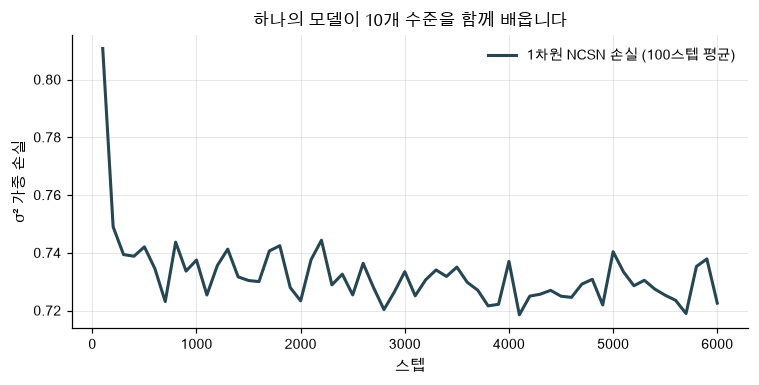

In [32]:
plot_curves(np.arange(1, 61) * 100, {"1차원 NCSN 손실 (100스텝 평균)": ncsn_history.reshape(60, 100).mean(axis=1)},
            title="하나의 모델이 10개 수준을 함께 배웁니다", ylabel="σ² 가중 손실")

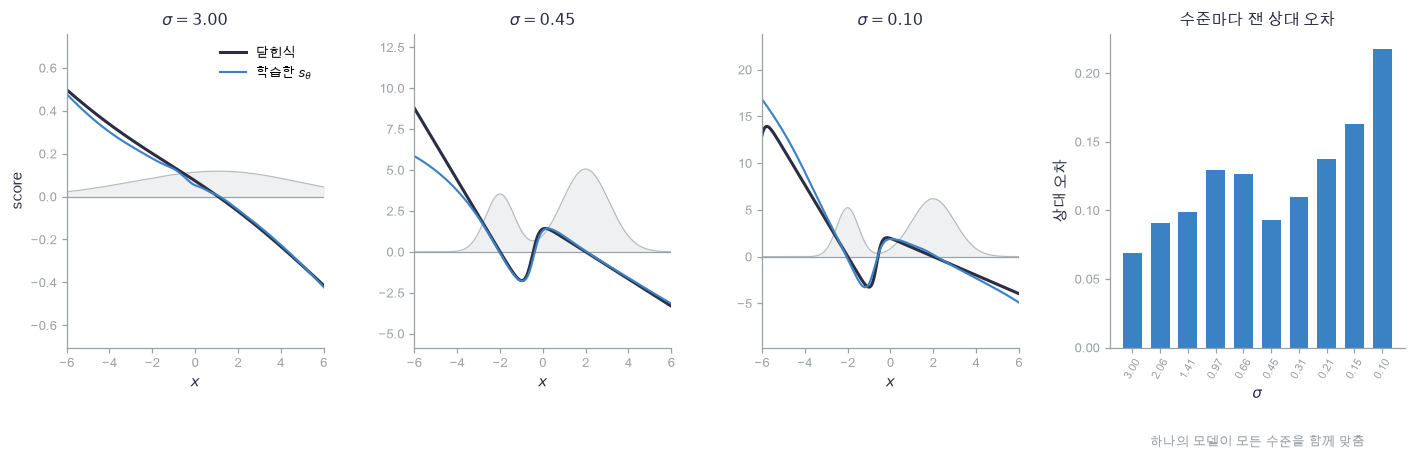

In [33]:
plot_learned_ladder(ladder_x, [ladder[0], ladder[5], ladder[9]],
                    [ncsn_weights[0], ncsn_weights[5], ncsn_weights[9]],
                    [ncsn_true[0], ncsn_true[5], ncsn_true[9]],
                    [ncsn_learned[0], ncsn_learned[5], ncsn_learned[9]], ladder, ncsn_rel)

🔍 **확인** · 세 수준 모두 학습한 곡선(파랑)이 닫힌식(검정)과 밀도가 있는 구간에서 겹칩니다. $\sigma=3$에서는 score가 완만해 거의 정확하고, $\sigma=0.1$에서는 가파른 부분에서 조금 어긋납니다(오른쪽 막대의 마지막 칸). 수준이 작아질수록 상대 오차가 커지는 것은 1절에서 본 그대로입니다. 그래도 **하나의 모델**이 10개 수준을 모두 쓸 만하게 맞춥니다.

같은 코드로 2차원 혼합도 학습합니다. 입력·출력 차원만 2가 됩니다.

In [34]:
# 쓰는 것: ladder (1절 사다리 셀) · dense_X (2절 경로 셀) · mix2_sample, mix2_logpdf, mix2_score_noisy (📎 혼합 셀) · init_ncsn, ncsn_forward, train_ncsn (3절) · train_rng, ncsn_rel (3절 1차원 학습 셀)
train_X2 = mix2_sample(4000, train_rng)                              # (4000, 2): 2차원 학습 데이터
ncsn_p2, ncsn_history2 = train_ncsn(train_X2, ladder, 6000, 332)
ncsn_p2_before = init_ncsn(2, 128, 332)
ncsn_rel2, ncsn_rel2_before = [], []
for sigma in ladder:
    true2 = mix2_score_noisy(dense_X, sigma)                         # (13431, 2): 닫힌식 벡터장
    learned2 = ncsn_forward(dense_X, np.full(len(dense_X), sigma), ncsn_p2)[0]
    before2 = ncsn_forward(dense_X, np.full(len(dense_X), sigma), ncsn_p2_before)[0]
    q2 = np.exp(mix2_logpdf(dense_X, sigma))                         # (13431,): q_σ 가중치
    scale2 = np.sqrt(np.sum(q2 * np.sum(true2 ** 2, axis=1)))
    ncsn_rel2.append(float(np.sqrt(np.sum(q2 * np.sum((learned2 - true2) ** 2, axis=1))) / scale2))
    ncsn_rel2_before.append(float(np.sqrt(np.sum(q2 * np.sum((before2 - true2) ** 2, axis=1))) / scale2))
assert max(ncsn_rel) < 0.45, "1차원에서 모든 수준의 상대 오차가 0.45 아래여야 합니다"
assert max(ncsn_rel2) < 0.45, "2차원에서 모든 수준의 상대 오차가 0.45 아래여야 합니다"
assert all(a < b / 3 for a, b in zip(ncsn_rel, ncsn_rel0)), "1차원에서 학습 뒤 오차가 학습 전의 1/3 아래여야 합니다"
assert all(a < b / 3 for a, b in zip(ncsn_rel2, ncsn_rel2_before)), "2차원에서도 학습 뒤 오차가 학습 전의 1/3 아래여야 합니다"
print(f"2차원 손실 {ncsn_history2[:100].mean():.3f} → {ncsn_history2[-300:].mean():.3f}")
print("2차원 수준별 상대 오차: 학습 전", np.round(ncsn_rel2_before, 2), "\n                   학습 후", np.round(ncsn_rel2, 3))

2차원 손실 1.453 → 1.284
2차원 수준별 상대 오차: 학습 전 [1.52 1.47 1.46 1.46 1.5  1.64 1.92 2.41 3.14 4.2 ] 
                   학습 후 [0.087 0.063 0.064 0.085 0.096 0.097 0.122 0.157 0.199 0.283]


🔍 **확인** · 2차원에서도 모든 수준의 상대 오차가 학습 전의 1/3 아래로 내려가고, 큰 $\sigma$에서 작은 $\sigma$까지 0.05–0.3 사이입니다. 이 하나의 모델 `ncsn_p2`가 4절의 annealed Langevin에 쓰일 벡터장입니다.

### ✏️ 연습 3 · $\sigma^2$ 가중 손실 한 줄

예측 `S` `(N, D)`, 잡음 `eps` `(N, D)`, 표본마다 다른 `sigma` `(N,)`에서 가중 손실 $J=\frac1N\sum_n\|\sigma_nS_n+\epsilon_n\|^2$과 출력 기울기 $\frac{\partial J}{\partial S}=\frac{2\sigma}{N}(\sigma S+\epsilon)$ 두 줄을 채우세요. `column` `(N, 1)`은 미리 세워 두었습니다. 좌표 축은 합, 관측 축은 평균입니다.

In [35]:
def exercise_weighted_loss(S, eps, sigma):
    """연습 3: σ² 가중 DSM 손실과 출력 기울기. S, eps: (N, D), sigma: (N,) → (loss: 숫자, dS: (N, D))."""
    assert S.shape == eps.shape, "예측과 잡음은 같은 (N, D) 모양이어야 합니다"
    column = np.reshape(sigma, (-1, 1))                              # (N, 1): 표본마다 다른 σ
    residual = column * S + eps                                      # (N, D): σ S + ε
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: loss = residual² 을 좌표 축으로 합한 뒤 관측 축으로 평균한 숫자, dS = 2 × column × residual / N (모양 (N, D))
    ### 힌트: 3절 ncsn_loss 의 마지막 줄입니다. np.mean(np.sum(residual ** 2, axis=1)) 이고 N 은 len(S) 입니다.
    raise NotImplementedError
    return loss, dS

In [36]:
def check_weighted_loss(candidate):
    """3절 손계산(5.28125), 본문 ncsn_loss, 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: ncsn_loss (3절)
    hand_S_c = np.array([[0.5], [-1.]])                                                     # (2, 1): 3절 손계산과 같은 예측
    hand_eps_c = np.array([[1.], [-1.]])                                                    # (2, 1): 3절 손계산과 같은 잡음
    loss_hand, dS_hand = candidate(hand_S_c, hand_eps_c, np.array([0.5, 2.0]))
    np.testing.assert_allclose(loss_hand, 5.28125)                                          # 검산: 손계산 (1.25² + 3²)/2
    np.testing.assert_allclose(dS_hand, [[0.625], [-6.]])                                   # 검산: 손계산 2σ(σS + ε)/N
    S_c = np.random.default_rng(3321).normal(size=(6, 2))
    e_c = np.random.default_rng(3322).normal(size=(6, 2))
    s_c = np.exp(np.random.default_rng(3323).uniform(-2, 1, size=6))                        # (6,): 표본마다 다른 σ
    loss_c, dS_c = candidate(S_c, e_c, s_c)
    np.testing.assert_allclose([loss_c], [ncsn_loss(S_c, e_c, s_c)[0]])                     # 검산: 본문 ncsn_loss 의 손실
    np.testing.assert_allclose(dS_c, ncsn_loss(S_c, e_c, s_c)[1])                           # 검산: 본문 ncsn_loss 의 기울기

    def loss_scalar():
        """검사기용: 후보의 손실값."""
        return float(candidate(S_c, e_c, s_c)[0])

    assert rel_error(dS_c, numerical_gradient(loss_scalar, S_c)) < 1e-7, "출력 기울기가 중심차분과 1e−7 안에서 같아야 합니다"
    print("σ² 가중 손실과 출력 기울기: 손계산·ncsn_loss·중심차분과 일치합니다.")

run_check(check_weighted_loss, exercise_weighted_loss, hint="loss = float(np.mean(np.sum(residual ** 2, axis=1))) · dS = 2 * column * residual / len(S)")

☐ exercise_weighted_loss: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: loss = float(np.mean(np.sum(residual ** 2, axis=1))) · dS = 2 * column * residual / len(S)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
loss = float(np.mean(np.sum(residual ** 2, axis=1)))
dS = 2 * column * residual / len(S)
```

</details>

## 🔑 4. annealed Langevin: 큰 잡음에서 작은 잡음으로 내려오기

**이 절에서 가져갈 것:** 수준 $\sigma_1$(가장 큼)부터 $\sigma_L$(가장 작음)까지 차례로, 수준마다 걸음 크기 $\alpha_i=\epsilon\,\sigma_i^2/\sigma_L^2$로 $T$번씩 Langevin을 돕니다. 큰 $\sigma$에서는 봉우리 사이를 자유롭게 넘나들어 **비율**이 정해지고, 작은 $\sigma$로 내려오면서 **자리**가 다듬어집니다.

2절에서 본 문제는 이랬습니다. 작은 $\sigma$의 Langevin은 정확하지만 그 수준에 맞는 짧은 걸음으로는 정해진 걸음 수 안에 처음 있던 봉우리를 벗어나지 못하고, 큰 $\sigma$의 Langevin은 잘 돌아다니지만 엉뚱한 분포의 샘플을 냅니다. 그러면 큰 $\sigma$에서 시작해 조금씩 $\sigma$를 줄이면 됩니다. 쇠를 달궜다가 천천히 식히는 담금질과 같아서 **annealing**이라고 부릅니다.

> **용어**
>
> - **annealed Langevin dynamics**: 사다리의 수준을 큰 것부터 작은 것까지 훑으며 수준마다 Langevin을 $T$번씩 도는 샘플링. 마지막 수준의 결과가 샘플입니다 (Song·Ermon 2019).
> - **걸음 크기 스케줄** $\alpha_i$: 수준마다 다른 $\alpha$. 여기서는 $\epsilon$ 하나로 전부 정합니다.

$$\text{for } i=1,\ldots,L:\quad \alpha_i=\epsilon\frac{\sigma_i^2}{\sigma_L^2},\qquad
\text{repeat } T \text{ times: } x\leftarrow x+\frac{\alpha_i}{2}s_\theta(x,\sigma_i)+\sqrt{\alpha_i}\,z.$$

$x$는 $(M,D)$이고 모든 입자가 함께 움직입니다. $\epsilon$은 **마지막 수준의 걸음 크기**입니다($i=L$이면 $\alpha_L=\epsilon$).

왜 $\sigma_i^2$에 비례할까요. 그 수준의 타깃 $-\epsilon/\sigma_i$의 크기가 $1/\sigma_i$이므로 score의 크기도 그 위쪽이 한계입니다(이 예제에서는 $\sigma$가 데이터 규모보다 작아지면 $1/\sigma_i$보다 훨씬 작습니다 — 3절 그림 왼쪽). 이 상한을 기준으로 한 걸음의 이동량은 $\frac{\alpha_i}{2}|s|\le\frac{\alpha_i}{2\sigma_i}$이고 잡음의 크기는 $\sqrt{\alpha_i}$이므로, 둘의 비는
$$\frac{\alpha_i/(2\sigma_i)}{\sqrt{\alpha_i}}=\frac{\sqrt{\alpha_i}}{2\sigma_i}=\frac{\sqrt\epsilon}{2\sigma_L}\quad\text{(모든 수준에서 같음)}.$$
즉 $\alpha_i\propto\sigma_i^2$은 그 상한을 기준으로 "**어느 수준에서나 걸음과 잡음의 비를 같게**" 두는 선택입니다. 아래 검산에서 $\sqrt{\alpha_i}/\sigma_i$가 정말 일정한지 확인합니다.

아래 계산 셀은 **정확한 $q_\sigma$ score**로 먼저 돌려 봅니다(알고리즘만 보기 위해서입니다). 입자 2,000개를 모두 **왼쪽 봉우리 한 점**에 모아 두고 출발합니다. 오른쪽 봉우리를 찾아낼 수 있을까요.

In [37]:
# 쓰는 것: ladder (1절 사다리 셀) · mix2_score_noisy, mix2_responsibility (📎 혼합 셀) · MIX2_MU (📎 데이터 셀) · MIX2_MEAN (📎 검산 셀)
anneal_eps = 0.01                                                    # 마지막 수준의 걸음 크기 α_L
anneal_T = 100                                                       # 수준마다 도는 걸음 수
anneal_alphas = anneal_eps * ladder ** 2 / ladder[-1] ** 2           # (10,): 수준별 걸음 크기
anneal_start = np.tile(MIX2_MU[0], (2000, 1))                        # (2000, 2): 모두 왼쪽 봉우리 한 점에서 출발
anneal_rng = np.random.default_rng(3309)
anneal_x = anneal_start.copy()
anneal_snapshots, anneal_fracs = [], []
for sigma, alpha in zip(ladder, anneal_alphas):
    for step in range(anneal_T):
        anneal_x = (anneal_x + alpha / 2 * mix2_score_noisy(anneal_x, sigma)
                    + np.sqrt(alpha) * anneal_rng.normal(size=anneal_x.shape))
    anneal_snapshots.append(anneal_x.copy())                         # 수준을 마칠 때마다 사진 한 장
    anneal_fracs.append(float(mix2_responsibility(anneal_x).mean(axis=0)[1]))   # 오른쪽 봉우리의 책임확률 평균
print("수준별 걸음 크기 α_i:", anneal_alphas.round(4))
print("수준별 오른쪽 봉우리 비율:", np.round(anneal_fracs, 3), "(닫힌식 π₂ = 0.6)")
print("최종 평균", anneal_x.mean(axis=0).round(3), "· 닫힌식 평균", MIX2_MEAN)

수준별 걸음 크기 α_i: [9.     4.2266 1.9849 0.9322 0.4378 0.2056 0.0965 0.0453 0.0213 0.01  ]
수준별 오른쪽 봉우리 비율: [0.604 0.571 0.569 0.582 0.587 0.598 0.594 0.59  0.588 0.586] (닫힌식 π₂ = 0.6)
최종 평균 [0.366 0.593] · 닫힌식 평균 [0.4 0.6]


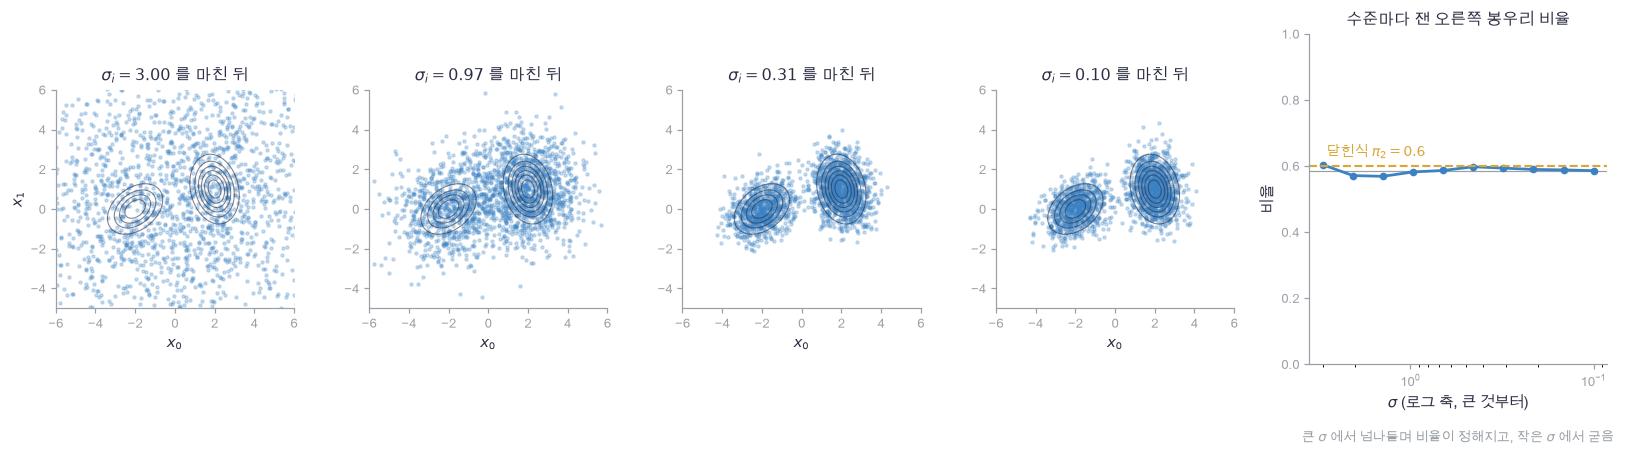

In [38]:
plot_annealed_snapshots([anneal_snapshots[0], anneal_snapshots[3], anneal_snapshots[6], anneal_snapshots[9]],
                        [ladder[0], ladder[3], ladder[6], ladder[9]],
                        dense_xx, dense_yy, dense_pdf, anneal_fracs, ladder)

🔍 **확인** · 첫 패널($\sigma_1=3$)에서 입자들은 출발점을 완전히 잊고 넓게 퍼져 있습니다. 걸음 크기가 $\alpha_1=9$로 크고 잡음이 $\sqrt9=3$이라 한 걸음에 봉우리 사이를 건너뜁니다. 수준을 내려갈수록 구름이 두 덩어리로 갈라지고, 마지막에는 등고선 안에 딱 맞게 들어갑니다.

오른쪽 막대(수준별 오른쪽 봉우리 비율)를 보세요. 모두 왼쪽 봉우리에서 출발했는데 **첫 수준이 끝난 시점에 이미 출발점을 잊었습니다**. 다만 $\sigma_1=3$에서는 봉우리가 아직 갈라지지 않아 이 막대 자체는 큰 뜻이 없습니다. 첫 패널처럼 한 덩어리로 퍼진 구름이면 봉우리가 없는 Gaussian에 같은 지표를 써도 거의 같은 값이 나오기 때문입니다. 봉우리가 갈라지기 시작하는 $\sigma\approx1$ 아래에서 비율이 0.6 근처로 굳고, 그 뒤 수준들은 그 비율을 유지한 채 자리만 다듬습니다. 이것이 annealing이 하는 일입니다.

아래 구현은 위 반복문을 함수로 옮긴 것입니다. 검산에서는 걸음 크기의 두 항등식, 위 계산과 같은 값이 나오는지, 최종 샘플의 평균·공분산이 혼합의 닫힌식과 맞는지, 그리고 **같은 걸음 수의 단일 $\sigma$ Langevin과 비교**합니다.

In [39]:
def annealed_langevin(score_fn, x0, sigmas, eps, steps_per_level, rng):
    """annealed Langevin: 큰 σ 부터 작은 σ 까지 수준마다 α_i = ε σ_i²/σ_L² 로 steps_per_level 번씩 Langevin.
    score_fn: (x, σ) → score, x0: (M, D) → (x: (M, D) 마지막 위치, snapshots: 수준마다의 (M, D) 목록)."""
    # 쓰는 것: langevin_step (2절)
    x = x0.copy()                                                    # 출발점을 바꾸지 않도록 복사
    snapshots = []
    for sigma in sigmas:
        alpha = eps * sigma ** 2 / sigmas[-1] ** 2                   # 이 수준의 걸음 크기
        for step in range(steps_per_level):
            x = langevin_step(x, score_fn(x, sigma), alpha, rng.normal(size=x.shape))
        snapshots.append(x.copy())
    return x, snapshots

In [40]:
# 쓰는 것: ladder (1절 사다리 셀) · anneal_eps, anneal_T, anneal_alphas, anneal_start, anneal_x (4절 계산 셀) · MIX2_MEAN, MIX2_COVARIANCE (📎 검산 셀) · mix2_score_noisy (📎 혼합 셀)
np.testing.assert_allclose(anneal_alphas / ladder ** 2, anneal_eps / ladder[-1] ** 2)    # 검산: α_i/σ_i² 이 모든 수준에서 같음
np.testing.assert_allclose(np.sqrt(anneal_alphas) / ladder, np.sqrt(anneal_eps) / ladder[-1])   # 검산: √α_i/σ_i 일정 (걸음과 잡음의 비)
np.testing.assert_allclose(anneal_alphas[-1], anneal_eps)            # 검산: 마지막 수준의 걸음 크기가 ε


def exact_ladder_score(x, sigma):
    """사다리 수준 σ 의 닫힌식 q_σ score (2차원). x: (M, 2) → (M, 2)."""
    return mix2_score_noisy(x, sigma)


exact_x, _ = annealed_langevin(exact_ladder_score, anneal_start, ladder, anneal_eps, anneal_T, np.random.default_rng(3309))
np.testing.assert_allclose(exact_x, anneal_x)                        # 검산: 위 계산 셀의 반복문과 같은 값
np.testing.assert_allclose(exact_x.mean(axis=0), MIX2_MEAN, atol=0.12)            # 검산: 샘플 평균 ≈ 닫힌식 평균
np.testing.assert_allclose(np.cov(exact_x.T), MIX2_COVARIANCE, atol=0.25)         # 검산: 샘플 공분산 ≈ 닫힌식 공분산
print("최종 샘플 평균", exact_x.mean(axis=0).round(3), "(닫힌식", MIX2_MEAN, ")")
print("공분산 최대 오차", np.abs(np.cov(exact_x.T) - MIX2_COVARIANCE).max().round(3))

최종 샘플 평균 [0.366 0.593] (닫힌식 [0.4 0.6] )
공분산 최대 오차 0.022


🔍 **확인** · 걸음 크기의 두 항등식이 그대로 성립하고, 함수로 옮긴 결과가 위 반복문과 완전히 같습니다. 한 점에서 출발했는데도 최종 샘플의 평균과 공분산이 혼합의 닫힌식과 맞습니다. 사다리 없이 마지막 수준 하나로만 걸었다면 어땠을까요.

### 🔍 사다리가 없으면 한 봉우리에 갇힙니다

같은 출발점, 같은 걸음 수(1,000걸음), 같은 걸음 크기 $\epsilon$으로 $\sigma_L$ 하나만 쓰는 Langevin과 비교합니다. 그다음 3절에서 **학습한** 모델 `ncsn_p2`로도 annealed Langevin을 돌려 봅니다.

In [41]:
# 쓰는 것: ladder, anneal_eps, anneal_T, anneal_start (4절) · langevin_step (2절) · ncsn_forward (3절) · ncsn_p2 (3절 2차원 학습 셀) · MIX2_MEAN, MIX2_COVARIANCE (📎 검산 셀) · mix2_responsibility (📎 혼합 셀)
single_x = anneal_start.copy()
single_rng = np.random.default_rng(3310)
for step in range(len(ladder) * anneal_T):                           # annealed 와 같은 총 걸음 수
    single_x = langevin_step(single_x, exact_ladder_score(single_x, ladder[-1]), anneal_eps, single_rng.normal(size=single_x.shape))


def learned_ladder_score(x, sigma):
    """3절에서 학습한 NCSN 이 내는 수준 σ 의 score. x: (M, 2) → (M, 2)."""
    return ncsn_forward(x, np.full(len(x), sigma), ncsn_p2)[0]


learned_x, _ = annealed_langevin(learned_ladder_score, anneal_start, ladder, anneal_eps, anneal_T, np.random.default_rng(3311))
coverage = [mix2_responsibility(x).mean(axis=0) for x in [exact_x, single_x, learned_x]]
assert coverage[0][1] > 0.45, "annealed Langevin 은 오른쪽 봉우리를 절반 가까이 채워야 합니다"
assert coverage[1][1] < 0.25, "단일 σ Langevin 은 출발한 왼쪽 봉우리에 갇혀야 합니다"
assert 0.35 < coverage[2][1] < 0.8, "학습한 모델의 annealed Langevin 도 두 봉우리를 모두 채워야 합니다"
assert np.linalg.norm(learned_x.mean(axis=0) - MIX2_MEAN) < 0.6, "학습한 모델의 샘플 평균이 닫힌식 평균에 가까워야 합니다"
print("봉우리 비율 (왼쪽, 오른쪽) · 닫힌식 (0.4, 0.6)")
for name, frac in zip(["annealed (정확한 score)", "단일 σ (정확한 score)", "annealed (학습한 s_θ)"], coverage):
    print(f"  {name}: {frac.round(3)}")
print("학습한 모델 샘플 평균", learned_x.mean(axis=0).round(3), "· 공분산 최대 오차",
      np.abs(np.cov(learned_x.T) - MIX2_COVARIANCE).max().round(3))

봉우리 비율 (왼쪽, 오른쪽) · 닫힌식 (0.4, 0.6)
  annealed (정확한 score): [0.414 0.586]
  단일 σ (정확한 score): [0.902 0.098]
  annealed (학습한 s_θ): [0.469 0.531]
학습한 모델 샘플 평균 [0.066 0.436] · 공분산 최대 오차 0.389


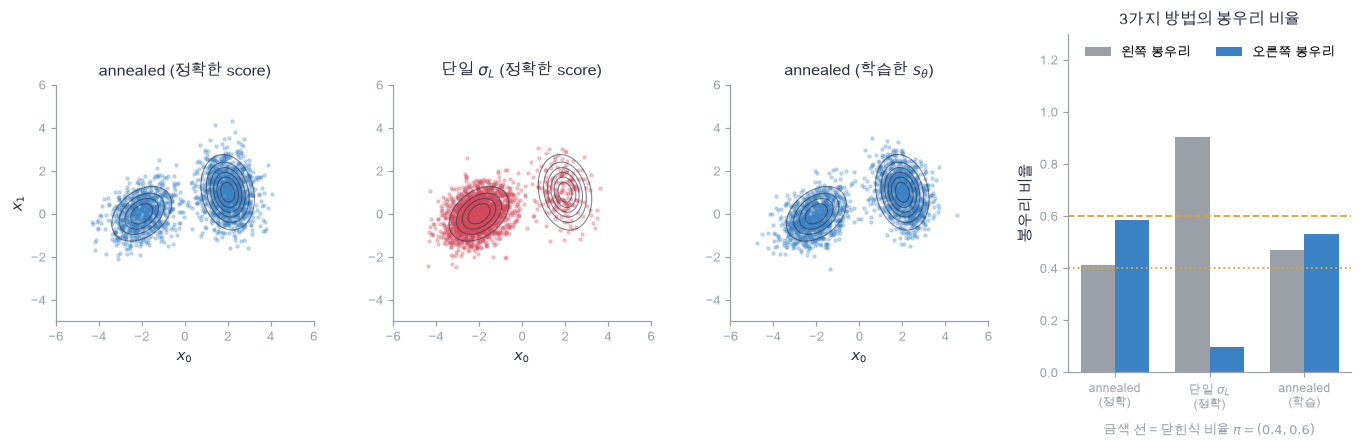

In [42]:
plot_coverage_compare([("annealed (정확한 score)", exact_x), ("단일 $\\sigma_L$ (정확한 score)", single_x),
                       ("annealed (학습한 $s_\\theta$)", learned_x)],
                      dense_xx, dense_yy, dense_pdf,
                      ["annealed\n(정확)", "단일 $\\sigma_L$\n(정확)", "annealed\n(학습)"], coverage)

🔍 **확인** · 가운데 패널이 단일 $\sigma_L$ Langevin입니다. 걸음 수도 걸음 크기도 같은데 입자가 거의 전부 왼쪽 봉우리에 남아 있습니다. $\sigma_L=0.1$에서는 두 봉우리 사이가 너무 깊어 1,000걸음으로는 건널 수 없습니다(2절에서 이미 본 것입니다). 왼쪽과 오른쪽 패널은 사다리를 쓴 결과이고, **정확한 score를 넣든 3절에서 학습한 $s_\theta$를 넣든** 두 봉우리가 모두 채워집니다.

학습한 모델의 샘플은 정확한 score의 것보다 조금 퍼져 있습니다. 1절에서 본 대로 작은 $\sigma$에서 오차가 남기 때문입니다. 그래도 봉우리 비율과 평균은 닫힌식에 가깝습니다. 학습용 작은 문제의 결과이며 실제 생성 모델의 품질로 읽지 마세요.

### ✏️ 연습 4 · 수준별 걸음 크기 스케줄

사다리 `sigmas` `(L,)`와 마지막 수준의 걸음 크기 `eps`에서 수준별 걸음 크기 $\alpha_i=\epsilon\,\sigma_i^2/\sigma_L^2$ 배열을 만드는 한 줄을 채우세요. 검사는 손계산(사다리 $[4,2,1]$, $\epsilon=0.5$이면 $[8,2,0.5]$), 마지막 항이 $\epsilon$인지, $\sqrt{\alpha_i}/\sigma_i$가 일정한지를 봅니다.

In [43]:
def exercise_alpha_schedule(sigmas, eps):
    """연습 4: annealed Langevin 의 수준별 걸음 크기. sigmas: (L,) 내림차순, eps: 양수 → (L,)."""
    assert sigmas[0] > sigmas[-1] > 0, "사다리는 큰 σ 에서 작은 σ 로 내려가야 합니다"
    assert eps > 0, "걸음 크기는 양수여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: alphas = ε × σ_i² / σ_L²   (모양 (L,), σ_L 은 sigmas[-1])
    ### 힌트: 4절 annealed_langevin 안의 한 줄을 배열로 한 것입니다. sigmas ** 2 는 원소별 제곱입니다.
    raise NotImplementedError
    return alphas

In [44]:
def check_alpha_schedule(candidate):
    """손계산 [8, 2, 0.5], 마지막 항 = ε, √α_i/σ_i 일정, 4절의 anneal_alphas 로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: ladder (1절 사다리 셀) · anneal_eps, anneal_alphas (4절 계산 셀)
    hand = candidate(np.array([4., 2., 1.]), 0.5)
    np.testing.assert_allclose(hand, [8., 2., 0.5])                   # 검산: 손계산 0.5 × (16, 4, 1)/1
    got = candidate(ladder, anneal_eps)
    np.testing.assert_allclose(got, anneal_alphas)                    # 검산: 4절 계산 셀의 걸음 크기
    np.testing.assert_allclose(got[-1], anneal_eps)                   # 검산: 마지막 수준의 걸음 크기가 ε
    np.testing.assert_allclose(np.sqrt(got) / ladder, np.sqrt(anneal_eps) / ladder[-1])   # 검산: √α_i/σ_i 가 일정
    print("걸음 크기 스케줄: 손계산·4절 값과 일치합니다.")

run_check(check_alpha_schedule, exercise_alpha_schedule, hint="alphas = eps * sigmas ** 2 / sigmas[-1] ** 2")

☐ exercise_alpha_schedule: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: alphas = eps * sigmas ** 2 / sigmas[-1] ** 2


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
alphas = eps * sigmas ** 2 / sigmas[-1] ** 2
```

</details>

## 🔑 5. MNIST PCA-32 좌표에서 NCSN

**이 절에서 가져갈 것:** 앞 네 절의 코드를 그대로 32차원 좌표에 쓰면 숫자 그림이 나옵니다. 바뀌는 것은 데이터 $X$의 차원과 사다리($\sigma_{\max}$·$\sigma_{\min}$), 걸음 크기 $\epsilon$, 그리고 모델 크기·학습 예산뿐이고 수식과 코드는 그대로입니다. $\sigma_{\max}$는 **데이터 점 쌍 거리의 최댓값**으로 잡습니다. 그래야 가장 큰 수준에서 어떤 점에서 어떤 점으로든 한 걸음에 갈 수 있습니다.

지금까지는 1차원과 2차원이었습니다. 이미지는 784차원인데, 그대로 다루면 이 노트북의 작은 MLP로는 벅찹니다. 11번의 주성분 32개로 줄인 좌표에서 학습하고, 만든 좌표를 되돌려 그림으로 봅니다.

> **용어**
>
> - **주성분 분석(PCA)**: 데이터가 가장 넓게 퍼진 방향부터 차례로 고른 축들. 공분산 행렬의 고유벡터입니다 (11번 3·4절). 코드에서 `np.linalg.eigh(mnist_cov)`.
> - **좌표(coordinate)** $z$: 이미지를 주성분 축에 투영한 숫자 32개. $z=(x-\mu)^\top Q$이고 되돌리면 $\hat x=zQ^\top+\mu$입니다.
> - **최대 쌍 거리**: 데이터 점 두 개 사이 거리 중 가장 먼 것. Song·Ermon 2020이 $\sigma_{\max}$의 기준으로 제안한 값입니다.

$Q$가 $(784,32)$이면 좌표는 다음과 같습니다. 전체 표준편차 하나로 나눠 규모를 1 근처로 맞춥니다(1·2차원 예제와 같은 규모로 두기 위해서입니다).

$$Z=\frac{(X-\mu)Q}{c},\quad c=\operatorname{std}\big((X-\mu)Q\big),\qquad
\hat X=cZQ^\top+\mu,\qquad
\sigma_{\max}=\max_{i,j}\lVert z_i-z_j\rVert.$$

$X$는 $(5000,784)$, $Z$는 $(5000,32)$, $\hat X$는 다시 $(5000,784)$입니다. 쌍 거리는 00b번 5절의 전개식 $\lVert a-b\rVert^2=\lVert a\rVert^2+\lVert b\rVert^2-2a^\top b$로 구하되, $5000\times5000$ 표를 한 번에 만들지 않고 1,000행씩 나눠 최댓값만 남깁니다.

아래 계산 셀은 좌표를 만들고, 고정 예시 7의 좌표에 사다리의 $\sigma$만큼 잡음을 더해 되돌린 그림을 만듭니다. 잡음이 커질수록 무엇이 남는지 보세요.

> **코드**
>
> - `np.linalg.eigh(C)`: 대칭 행렬의 고유값(오름차순)과 고유벡터. `[:, ::-1]`로 열 순서를 뒤집으면 큰 고유값부터입니다 (11번 3절).
> - `Z[start:start + 1000] @ Z.T`: 1,000행씩 잘라 곱해 큰 표를 한 번에 만들지 않습니다.

In [45]:
# 쓰는 것: mnist_X (📎 데이터 셀) · sigma_ladder (1절)
mnist_mu = mnist_X.mean(axis=0)                                      # (784,): 평균 이미지
mnist_centered = mnist_X - mnist_mu                                  # (5000, 784)
mnist_cov = mnist_centered.T @ mnist_centered / len(mnist_X)         # (784, 784): 공분산 (11번 2절)
mnist_values, mnist_vectors = np.linalg.eigh(mnist_cov)              # 고유값 오름차순, 고유벡터는 열 (11번 3절)
mnist_Q = mnist_vectors[:, ::-1][:, :32]                             # (784, 32): 가장 넓게 퍼진 32개 방향
mnist_raw = mnist_centered @ mnist_Q                                 # (5000, 32): 원래 규모의 좌표
mnist_scale = float(mnist_raw.std())                                 # 전체 표준편차 하나
mnist_Z = mnist_raw / mnist_scale                                    # (5000, 32): 단위 규모 좌표
mnist_squared = np.sum(mnist_Z ** 2, axis=1)                         # (5000,): ‖z‖²
mnist_far = 0.0
for start in range(0, len(mnist_Z), 1000):                           # 1,000행씩 나눠 쌍 거리의 최댓값만 남김
    block = mnist_squared[start:start + 1000, None] + mnist_squared[None, :] - 2 * mnist_Z[start:start + 1000] @ mnist_Z.T
    mnist_far = max(mnist_far, float(block.max()))
mnist_sigma_max = float(np.sqrt(mnist_far))                          # σ_max = 최대 쌍 거리
mnist_ladder = sigma_ladder(mnist_sigma_max, 0.05, 10)               # (10,): 이미지 좌표용 사다리 (σ_min 은 1·2차원보다 작게)
print("설명한 분산 비율", round(float(mnist_values[::-1][:32].sum() / mnist_values.sum()), 4),
      "· 좌표 규모 c =", round(mnist_scale, 3), "· σ_max =", round(mnist_sigma_max, 3))
print("사다리:", mnist_ladder.round(3))

설명한 분산 비율 0.7491 · 좌표 규모 c = 1.11 · σ_max = 13.214
사다리: [13.214  7.111  3.827  2.059  1.108  0.596  0.321  0.173  0.093  0.05 ]


In [46]:
# 쓰는 것: mnist_examples (📎 데이터 셀) · mnist_mu, mnist_Q, mnist_scale, mnist_ladder (5절 좌표 셀)
seven_z = (mnist_examples[7].reshape(784) - mnist_mu) @ mnist_Q / mnist_scale     # (32,): 고정 예시 7의 좌표
seven_recon = (seven_z * mnist_scale @ mnist_Q.T + mnist_mu).reshape(28, 28)      # (28, 28): 좌표만으로 되돌린 7
seven_sigmas = [mnist_ladder[7], mnist_ladder[5], mnist_ladder[4], mnist_ladder[2]]     # 작은 σ 부터 큰 σ 까지 네 수준
seven_rng = np.random.default_rng(3312)
seven_noisy = [((seven_z + sigma * seven_rng.normal(size=32)) * mnist_scale @ mnist_Q.T + mnist_mu).reshape(28, 28)
               for sigma in seven_sigmas]                            # 좌표에 잡음을 더해 되돌린 그림 네 장
print("7의 좌표 앞 다섯 개:", seven_z[:5].round(3), "· 복원 오차(화소 평균 제곱)",
      round(float(np.mean((seven_recon.reshape(784) - mnist_examples[7].reshape(784)) ** 2)), 5))

7의 좌표 앞 다섯 개: [ 2.515 -1.227  0.859  1.164  1.562] · 복원 오차(화소 평균 제곱) 0.01255


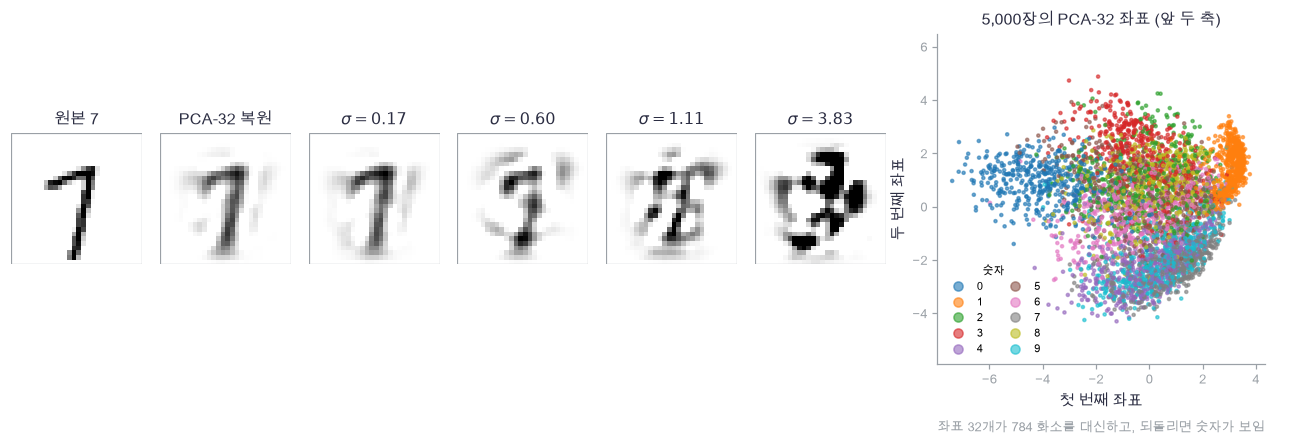

In [47]:
plot_pca_ladder(mnist_examples[7], seven_recon, seven_noisy, seven_sigmas, mnist_Z[:, :2], mnist_y)

🔍 **확인** · 왼쪽 두 장을 비교하면 좌표 32개만으로도 7의 모양이 거의 그대로 남습니다(잃은 것은 얇은 획의 가장자리뿐입니다). 오른쪽으로 갈수록 $\sigma$가 커지고, $\sigma\approx1$을 넘으면 어느 숫자였는지 알 수 없게 됩니다. $\sigma_{\max}=13.2$에서는 데이터가 아니라 넓은 Gaussian 구름 하나입니다.

맨 오른쪽 산점은 5,000장의 좌표를 앞 두 축에 찍은 것입니다. 숫자마다 자리가 다르지만 뚜렷이 갈라지지는 않습니다. 32차원에서 갈라지는 것을 2차원으로 눌러 본 것이라 그렇습니다. 이 구름이 이 절에서 배울 분포입니다.

아래 구현은 좌표를 이미지로 되돌리는 함수와 최대 쌍 거리 함수입니다. 검산은 $Q^\top Q=I$, 복원 오차, 그리고 작은 집합에서 모든 쌍을 그대로 재 본 값과 비교합니다.

In [48]:
def mnist_decode(Z):
    """단위 규모 좌표를 이미지로 되돌립니다 x̂ = c z Qᵀ + μ. Z: (N, 32) → (N, 28, 28)."""
    # 쓰는 것: mnist_scale, mnist_Q, mnist_mu (5절 좌표 셀)
    flat = Z * mnist_scale @ mnist_Q.T + mnist_mu                    # (N, 784)
    return flat.reshape(len(Z), 28, 28)


def max_pair_distance(Z, chunk=1000):
    """모든 점 쌍의 거리 중 최댓값 (00b 5절의 전개식 ‖a−b‖² = ‖a‖² + ‖b‖² − 2aᵀb 를 chunk 행씩).
    Z: (N, D) → 숫자."""
    squared = np.sum(Z ** 2, axis=1)                                 # (N,): ‖z‖²
    biggest = 0.0
    for start in range(0, len(Z), chunk):
        block = squared[start:start + chunk, None] + squared[None, :] - 2 * Z[start:start + chunk] @ Z.T
        biggest = max(biggest, float(block.max()))
    return float(np.sqrt(biggest))

In [49]:
# 쓰는 것: mnist_Q, mnist_Z, mnist_centered, mnist_sigma_max (5절 좌표 셀) · seven_z, seven_recon (5절 7 셀) · mnist_X (📎 데이터 셀)
np.testing.assert_allclose(mnist_Q.T @ mnist_Q, np.eye(32), atol=1e-10)    # 검산: 주성분 축은 서로 직교하고 길이 1
np.testing.assert_allclose(mnist_decode(seven_z[None])[0], seven_recon)     # 검산: 위 계산 셀의 복원과 같음
recon_error = float(np.mean((mnist_decode(mnist_Z).reshape(5000, 784) - mnist_X) ** 2))
data_variance = float(np.mean(mnist_centered ** 2))
assert recon_error < 0.3 * data_variance, "32개 좌표로 되돌린 오차는 원래 분산의 30% 아래여야 합니다"
small_Z = mnist_Z[:300]                                                     # (300, 32): 모든 쌍을 그대로 재 볼 작은 집합
brute = float(np.linalg.norm(small_Z[:, None] - small_Z[None, :], axis=2).max())   # 전개식 없이 직접 잰 최대 거리
np.testing.assert_allclose(max_pair_distance(small_Z), brute, rtol=1e-10)   # 검산: 전개식 = 직접 잰 값
np.testing.assert_allclose(max_pair_distance(mnist_Z), mnist_sigma_max)     # 검산: 위 계산 셀의 σ_max
print("복원 오차", round(recon_error, 5), "· 원래 분산", round(data_variance, 5),
      "· 최대 쌍 거리 (300장 직접)", round(brute, 3), "= 전개식", round(max_pair_distance(small_Z), 3))

복원 오차 0.01684 · 원래 분산 0.06714 · 최대 쌍 거리 (300장 직접) 12.084 = 전개식 12.084


🔍 **확인** · 주성분 축 32개가 서로 직교하고, 좌표만으로 되돌린 오차가 원래 분산의 25% 정도입니다. 300장에서 모든 쌍을 그대로 잰 최대 거리와 전개식으로 잰 값이 같습니다. 이제 앞 절의 `train_ncsn`과 `annealed_langevin`을 **그대로** 32차원 좌표에 씁니다. 바뀌는 것은 데이터와 사다리($\sigma_{\max}=13.2$, $\sigma_{\min}=0.05$), 걸음 크기 $\epsilon$, 모델 크기·학습 예산(은닉 256, 배치 256, 학습률 $10^{-3}$, 8,000스텝)뿐입니다.

$\epsilon$도 함께 바꾸는 이유는 이렇습니다. 4절의 $\alpha_i=\epsilon\,\sigma_i^2/\sigma_L^2$에서 $\epsilon$은 **마지막 수준의 걸음 크기**라 $\sigma_L$이 달라지면 같이 달라져야 합니다. 4절은 $\sigma_L=0.1$에 $\epsilon=0.01$이었으므로 같은 비 $\epsilon/\sigma_L^2=1$을 유지하려면 $\sigma_L=0.05$인 여기서는 $\epsilon=0.0025$입니다. 그대로 $0.05$를 쓰면 $\alpha_1=\epsilon\sigma_1^2/\sigma_L^2$가 너무 커서 첫 수준의 좌표가 $q_{\sigma_1}$의 규모를 몇 배씩 넘어갑니다.

In [50]:
# 쓰는 것: mnist_Z, mnist_y, mnist_ladder (5절 좌표 셀) · train_ncsn, ncsn_forward (3절)
# 1·2차원과 다른 것: 은닉 256, 배치 256, 학습률 1e-3, 8,000스텝
mnist_p, mnist_history = train_ncsn(mnist_Z, mnist_ladder, 8000, 333, batch=256, hidden=256, lr=1e-3)
mnist_class_means = np.stack([mnist_Z[mnist_y == digit].mean(axis=0) for digit in range(10)])   # (10, 32): 클래스 평균 (00b 5절)


def mnist_score(Z, sigma):
    """학습한 NCSN 이 내는 수준 σ 의 score (32차원 좌표). Z: (M, 32) → (M, 32)."""
    return ncsn_forward(Z, np.full(len(Z), sigma), mnist_p)[0]


def nearest_class(Z):
    """좌표를 클래스 평균 최근접으로 숫자에 붙입니다 (00b 5절). 분류기가 아니라 세는 도구입니다. Z: (M, 32) → (M,)."""
    return np.argmin(np.sum((Z[:, None] - mnist_class_means[None]) ** 2, axis=2), axis=1)


print(f"MNIST 좌표 손실 {mnist_history[:100].mean():.2f} → {mnist_history[-300:].mean():.2f}")
print("클래스 평균 최근접이 학습 데이터에서 맞히는 비율:", round(float(np.mean(nearest_class(mnist_Z) == mnist_y)), 3))

MNIST 좌표 손실 21.57 → 15.05
클래스 평균 최근접이 학습 데이터에서 맞히는 비율: 0.803


In [51]:
# 쓰는 것: mnist_ladder, mnist_Z (5절 좌표 셀) · annealed_langevin (4절) · mnist_score, nearest_class, mnist_decode (5절)
mnist_eps = 0.0025                                                   # 마지막 수준의 걸음 크기 α_L. σ_L = 0.05 라 4절(σ_L = 0.1, ε = 0.01)과 ε/σ_L² = 1 을 맞춘 값
sample_rng = np.random.default_rng(3315)
sample_start = sample_rng.normal(size=(16, 32)) * mnist_ladder[0]     # (16, 32): σ_max 규모의 Gaussian 구름에서 출발
sample_Z, _ = annealed_langevin(mnist_score, sample_start, mnist_ladder, mnist_eps, 100, sample_rng)
sample_images = mnist_decode(sample_Z)                               # (16, 28, 28)
sample_digits = nearest_class(sample_Z)                              # (16,): 가장 가까운 클래스 평균
sample_counts = np.bincount(sample_digits, minlength=10)             # (10,): 숫자별 개수
sample_norm = float(np.linalg.norm(sample_Z, axis=1).mean())
data_norm = float(np.linalg.norm(mnist_Z, axis=1).mean())
assert 0.6 * data_norm < sample_norm < 1.4 * data_norm, "샘플 좌표의 크기가 데이터와 같은 규모여야 합니다"
assert np.count_nonzero(sample_counts) >= 3, "만든 16장에 서로 다른 숫자가 3가지 이상 있어야 합니다"
print("샘플 좌표의 평균 길이", round(sample_norm, 2), "· 데이터", round(data_norm, 2))
print("숫자별 개수", sample_counts, "· 서로 다른 숫자", int(np.count_nonzero(sample_counts)), "가지")

샘플 좌표의 평균 길이 4.4 · 데이터 5.59
숫자별 개수 [1 8 0 1 4 0 0 0 0 2] · 서로 다른 숫자 5 가지


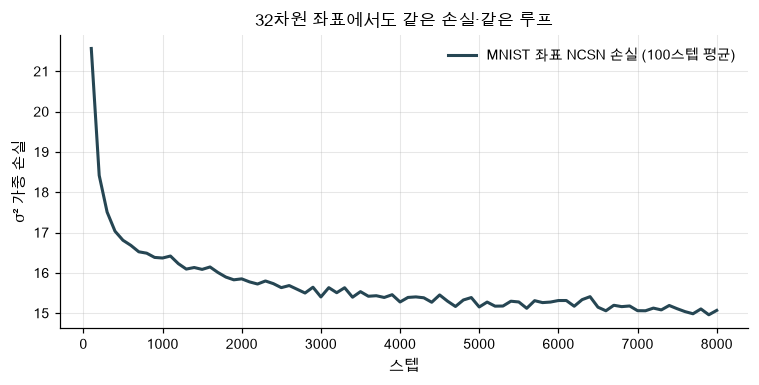

In [52]:
plot_curves(np.arange(1, 81) * 100, {"MNIST 좌표 NCSN 손실 (100스텝 평균)": mnist_history.reshape(80, 100).mean(axis=1)},
            title="32차원 좌표에서도 같은 손실·같은 루프", ylabel="σ² 가중 손실")

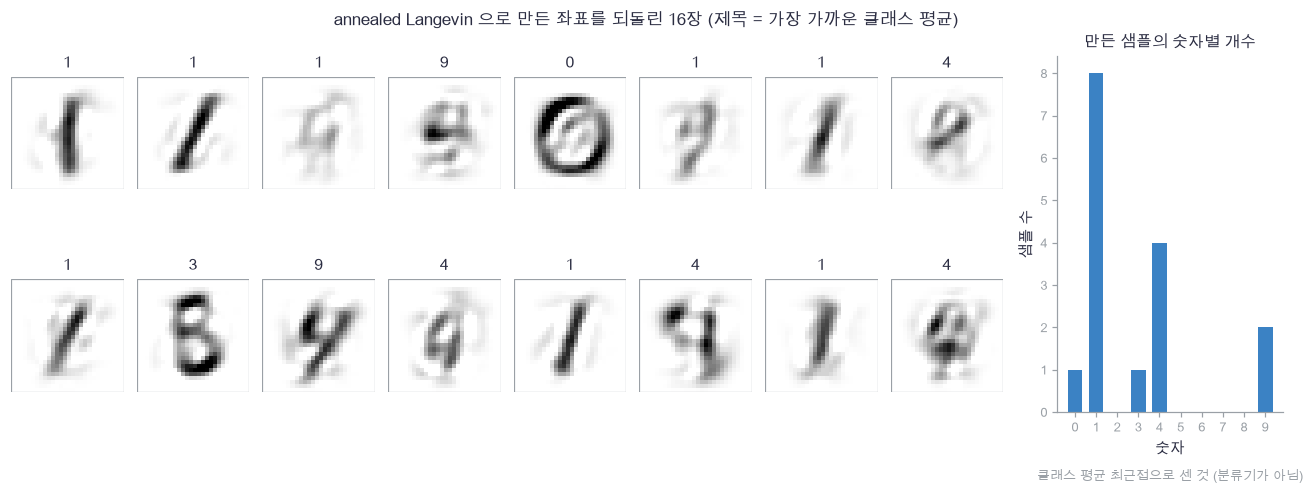

In [53]:
plot_sample_grid(sample_images, sample_digits, sample_counts,
                 "annealed Langevin 으로 만든 좌표를 되돌린 16장 (제목 = 가장 가까운 클래스 평균)")

🔍 **확인** · 잡음에서 출발한 좌표가 숫자처럼 보이는 그림으로 바뀝니다. 획이 흐릿하고 몇 장은 어느 숫자인지 애매합니다. 당연합니다. 주성분 32개는 원래 분산의 4분의 3만 담고 있고, 모델은 은닉 256짜리 MLP 하나이며 학습은 8,000스텝입니다. **학습용 작은 문제의 결과**이며 실제 생성 모델의 품질로 읽지 마세요.

숫자별 개수 막대를 보면 몇 숫자에 몰려 있습니다. 좌표 공간에서 봉우리가 뚜렷하지 않고(위 산점), 작은 $\sigma$에서의 score 오차가 남아 있어서입니다. 그래도 **잡음 하나에서 시작해 사다리를 내려오는 것만으로** 숫자 모양이 만들어진다는 것이 이 절의 요점입니다. 34번은 이 사다리를 시간 축으로 바꾸어 같은 일을 더 촘촘하게 합니다.

### ✏️ 연습 5 · $\sigma_{\max}$ = 최대 쌍 거리

좌표 `Z` `(N, D)`에서 모든 점 쌍의 거리 중 최댓값을 구하는 두 줄을 채우세요. `squared` `(N,)`은 미리 구해 두었습니다. 전개식 $\lVert a-b\rVert^2=\lVert a\rVert^2+\lVert b\rVert^2-2a^\top b$를 쓰면 표 하나로 모든 쌍이 나옵니다(작은 `Z`만 다루므로 나누지 않아도 됩니다).

In [54]:
def exercise_max_pair_distance(Z):
    """연습 5: 모든 점 쌍의 거리 중 최댓값. Z: (N, D) (N 이 작다고 가정) → 숫자."""
    assert Z.ndim == 2, "좌표는 (N, D) 모양이어야 합니다"
    squared = np.sum(Z ** 2, axis=1)                                 # (N,): ‖z‖²
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: pairs = 전개식으로 만든 (N, N) 제곱 거리 표, biggest = √(그 최댓값)
    ### 힌트: 5절 max_pair_distance 의 block 줄에서 잘라 내기를 빼면 squared[:, None] + squared[None, :] - 2 * Z @ Z.T 입니다.
    raise NotImplementedError
    return biggest

In [55]:
def check_max_pair_distance(candidate):
    """정사각형 네 꼭짓점의 손계산(대각선 √2), 직접 잰 거리, 5절 σ_max 로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: mnist_Z, mnist_sigma_max (5절 좌표 셀) · max_pair_distance (5절)
    square = np.array([[0., 0.], [1., 0.], [0., 1.], [1., 1.]])      # (4, 2): 한 변이 1인 정사각형
    np.testing.assert_allclose(candidate(square), np.sqrt(2.))       # 검산: 대각선 √2
    points = np.random.default_rng(3331).normal(size=(40, 3))
    brute = float(np.linalg.norm(points[:, None] - points[None, :], axis=2).max())
    np.testing.assert_allclose(candidate(points), brute, rtol=1e-10)  # 검산: 모든 쌍을 직접 잰 값
    np.testing.assert_allclose(candidate(mnist_Z[:500]), max_pair_distance(mnist_Z[:500]))   # 검산: 본문 함수와 같음
    assert candidate(mnist_Z[:500]) <= mnist_sigma_max, "일부만 본 최대 거리는 전체의 최대 거리를 넘을 수 없습니다"
    print("최대 쌍 거리: 손계산·직접 잰 값·본문 함수와 일치합니다.")

run_check(check_max_pair_distance, exercise_max_pair_distance, hint="pairs = squared[:, None] + squared[None, :] - 2 * Z @ Z.T · biggest = float(np.sqrt(pairs.max()))")

☐ exercise_max_pair_distance: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: pairs = squared[:, None] + squared[None, :] - 2 * Z @ Z.T · biggest = float(np.sqrt(pairs.max()))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
pairs = squared[:, None] + squared[None, :] - 2 * Z @ Z.T
biggest = float(np.sqrt(pairs.max()))
```

</details>

## ✏️ 6. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 2차원 $q_\sigma$의 score (1절)

2차원 점 `X` `(N, 2)`와 잡음 크기 `sigma`에서 $\nabla\log q_\sigma(x)=\sum_kr_k^\sigma(x)(\Sigma_k+\sigma^2I)^{-1}(\mu_k-x)$를 만듭니다. 성분 반복문과 책임확률 `R`은 써 두었으니 성분 $k$의 기여를 `S`에 더하는 한 줄을 채우세요. 1차원의 $1/(\sigma_k^2+\sigma^2)$이 2차원에서는 $(\Sigma_k+\sigma^2I)^{-1}$(연립방정식 풀기)로 바뀝니다.

In [56]:
def exercise_mix2_noisy_score(X, sigma):
    """연습 A: 2차원 q_σ 의 닫힌식 score. X: (N, 2), sigma: 숫자 → S: (N, 2)."""
    R = mix2_responsibility(X, sigma)                                # (N, 2): 분산 Σ_k + σ²I 의 책임확률
    S = np.zeros_like(X)                                             # (N, 2): 성분 기여를 여기에 더합니다
    for k in range(2):
        covariance = MIX2_COV[k] + sigma ** 2 * np.eye(2)            # (2, 2): 잡음을 더한 공분산
        ### 이 주석 아래에 다음을 구현하세요.
        ### 구현할 내용: S 에 R[:, k] 로 가중한 (Σ_k + σ²I)⁻¹(μ_k − X) 를 더하기 (모양 (N, 2))
        ### 힌트: 📎 혼합 셀 mix2_score_noisy 의 한 줄. np.linalg.solve(covariance, (MIX2_MU[k] - X).T).T 에 R[:, k:k + 1] 을 곱합니다.
        raise NotImplementedError
    return S

In [57]:
def check_mix2_noisy_score(candidate):
    """책임확률이 성분 0 에 몰리는 손계산, σ = 0 이면 원래 score, 본문 함수와 log q_σ 의 중심차분으로 검사합니다."""
    # 쓰는 것: MIX2_MU (📎 데이터 셀) · mix2_score_noisy, mix2_logpdf (📎 혼합 셀)
    far_X = MIX2_MU[0] + np.array([[-6., 0.]])                       # (1, 2): 성분 0 쪽으로 멀리 (책임확률 ≈ (1, 0))
    np.testing.assert_allclose(candidate(far_X, 0.0), [[-6 * -0.5 / 0.26, -6 * 0.2 / 0.26]], rtol=1e-6)   # 검산: Σ_0⁻¹(6, 0), det = 0.6·0.5 − 0.2² = 0.26
    X_c = np.random.default_rng(3341).uniform(-3, 3, size=(5, 2))
    for sigma in [0.0, 0.3, 1.5]:
        np.testing.assert_allclose(candidate(X_c, sigma), mix2_score_noisy(X_c, sigma))   # 검산: 본문 mix2_score_noisy 와 같음

    def logq_c():
        """검사기용: 검사 점들의 log q_σ (σ = 0.7) 합."""
        return float(np.sum(mix2_logpdf(X_c, 0.7)))

    assert rel_error(candidate(X_c, 0.7), numerical_gradient(logq_c, X_c)) < 1e-7, "중심차분과 1e−7 안에서 같아야 합니다"
    print("2차원 q_σ 의 score: 손계산·본문 함수·중심차분과 일치합니다.")

run_check(check_mix2_noisy_score, exercise_mix2_noisy_score, hint="S += R[:, k:k + 1] * np.linalg.solve(covariance, (MIX2_MU[k] - X).T).T")

☐ exercise_mix2_noisy_score: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: S += R[:, k:k + 1] * np.linalg.solve(covariance, (MIX2_MU[k] - X).T).T


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
S += R[:, k:k + 1] * np.linalg.solve(covariance, (MIX2_MU[k] - X).T).T
```

</details>

### ✏️ 연습 B · Langevin 반복문 (2절)

출발점 `x0` `(M,)`에서 `steps`번 Langevin을 반복해 마지막 위치를 돌려줍니다. 반복문과 난수 생성기는 써 두었으니 한 걸음 갱신 한 줄을 채우세요. score는 넘겨받은 `score_fn`으로 그 자리에서 계산합니다.

In [58]:
def exercise_langevin_run(score_fn, x0, alpha, steps, rng):
    """연습 B: Langevin 을 steps 번 반복. score_fn: x → 같은 모양, x0: (M,) → (M,)."""
    assert alpha > 0, "걸음 크기는 양수여야 합니다"
    x = x0.copy()                                                    # 출발점을 바꾸지 않도록 복사
    for step in range(steps):
        ### 이 주석 아래에 다음을 구현하세요.
        ### 구현할 내용: x 를 langevin_step 으로 한 걸음 갱신 (score 는 score_fn(x), 잡음은 rng.normal(size=x.shape))
        ### 힌트: 2절 langevin 의 반복문 안 한 줄입니다.
        raise NotImplementedError
    return x

In [59]:
def check_langevin_run(candidate):
    """steps = 0 이면 그대로, 같은 seed 면 본문 langevin 과 같은 값, 표준정규에서 정상 분산 1/(1 − α/4) 로 검사합니다."""
    # 쓰는 것: langevin (2절) · normal_score (2절 편향 검산 셀)
    x0_c = np.array([1., -2., 0.5])
    np.testing.assert_allclose(candidate(normal_score, x0_c, 0.2, 0, np.random.default_rng(1)), x0_c)   # 검산: 0 걸음이면 출발점 그대로
    got = candidate(normal_score, x0_c, 0.2, 5, np.random.default_rng(3351))
    np.testing.assert_allclose(got, langevin(normal_score, x0_c, 0.2, 5, np.random.default_rng(3351)))  # 검산: 같은 seed 면 본문 langevin 과 같음
    final = candidate(normal_score, np.zeros(20000), 0.4, 400, np.random.default_rng(3352))
    np.testing.assert_allclose(final.var(), 1 / (1 - 0.4 / 4), rtol=0.03)                               # 검산: 닫힌식 정상 분산 1/(1 − α/4)
    print("Langevin 반복문: 본문 함수·닫힌식 정상 분산과 일치합니다.")

run_check(check_langevin_run, exercise_langevin_run, hint="x = langevin_step(x, score_fn(x), alpha, rng.normal(size=x.shape))")

☐ exercise_langevin_run: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: x = langevin_step(x, score_fn(x), alpha, rng.normal(size=x.shape))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
x = langevin_step(x, score_fn(x), alpha, rng.normal(size=x.shape))
```

</details>

### ✏️ 연습 C · 출력을 $\sigma$로 나눈 자리의 backward (3절)

NCSN의 출력은 $s=U/\sigma$입니다. 그러면 $U$로 돌아가는 기울기는 $dU=dS/\sigma$이고, 마지막 층의 기울기는 03번 5절 그대로 $dW_3=H_2^\top dU$입니다. 두 줄을 채우세요. 이 $1/\sigma$가 $\sigma^2$ 가중과 짝을 이뤄 모든 수준을 같은 크기로 만듭니다.

In [60]:
def exercise_ncsn_head_backward(dS, cache, p):
    """연습 C: NCSN backward 의 첫 두 식. dS: (N, D), cache: ncsn_forward 의 것 → (dU: (N, D), dW3: (hidden, D))."""
    inputs, H1, H2, column = cache
    assert dS.shape == (len(H2), p["W3"].shape[1]), "dS 는 출력과 같은 (N, D) 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dU = dS 를 column(σ)으로 나눈 (N, D), dW3 = H2ᵀ dU (모양 (hidden, D))
    ### 힌트: 3절 ncsn_backward 의 첫 줄과 반환 사전의 "W3" 항목입니다. s = U/σ 라서 U 로 가는 기울기는 σ 로 나뉩니다.
    raise NotImplementedError
    return dU, dW3

In [61]:
def check_ncsn_head_backward(candidate):
    """σ = 2 인 손계산, 본문 ncsn_backward 의 dW3, 손실의 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: ncsn_forward, ncsn_backward, ncsn_loss, init_ncsn (3절)
    hand_cache = (np.zeros((2, 3)), np.zeros((2, 4)), np.array([[1., 0., 0., 2.], [0., 1., 0., 0.]]), np.array([[2.], [2.]]))
    hand_p = {"W3": np.zeros((4, 1))}
    dU_hand, dW3_hand = candidate(np.array([[4.], [-2.]]), hand_cache, hand_p)
    np.testing.assert_allclose(dU_hand, [[2.], [-1.]])                                  # 검산: 손계산 dS/σ = (4/2, −2/2)
    np.testing.assert_allclose(dW3_hand, [[2.], [-1.], [0.], [4.]])                     # 검산: 손계산 H2ᵀ dU
    small_p = init_ncsn(2, 6, 7)
    X_c = np.random.default_rng(3361).normal(size=(4, 2))
    eps_c = np.random.default_rng(3362).normal(size=(4, 2))
    sigma_c = np.array([0.2, 0.5, 1.0, 2.0])
    S_c, cache_c = ncsn_forward(X_c, sigma_c, small_p)
    dS_c = ncsn_loss(S_c, eps_c, sigma_c)[1]
    np.testing.assert_allclose(candidate(dS_c, cache_c, small_p)[1], ncsn_backward(dS_c, cache_c, small_p)["W3"])   # 검산: 본문 backward 와 같음

    def loss_c():
        """검사기용: 현재 파라미터의 σ² 가중 손실."""
        return ncsn_loss(ncsn_forward(X_c, sigma_c, small_p)[0], eps_c, sigma_c)[0]

    assert rel_error(candidate(dS_c, cache_c, small_p)[1], numerical_gradient(loss_c, small_p["W3"])) < 1e-6, "dW3 이 중심차분과 1e−6 안에서 같아야 합니다"
    print("출력을 σ 로 나눈 자리의 backward: 손계산·ncsn_backward·중심차분과 일치합니다.")

run_check(check_ncsn_head_backward, exercise_ncsn_head_backward, hint="dU = dS / column · dW3 = H2.T @ dU")

☐ exercise_ncsn_head_backward: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dU = dS / column · dW3 = H2.T @ dU


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dU = dS / column
dW3 = H2.T @ dU
```

</details>

### ✏️ 연습 D · annealing의 바깥 루프 (4절)

수준마다 걸음 크기를 정하고 그 수준에서 `steps_per_level`번 Langevin을 도는 두 겹 반복문입니다. 바깥 루프와 걸음 크기는 써 두었으니 안쪽 한 걸음을 채우세요. score 함수는 `(x, sigma)` 두 인자를 받습니다.

In [62]:
def exercise_anneal_loop(score_fn, x0, sigmas, eps, steps_per_level, rng):
    """연습 D: annealed Langevin 의 두 겹 반복문. score_fn: (x, σ) → score, x0: (M, D) → (M, D)."""
    assert sigmas[0] > sigmas[-1] > 0, "사다리는 큰 σ 에서 작은 σ 로 내려가야 합니다"
    x = x0.copy()                                                    # 출발점을 바꾸지 않도록 복사
    for sigma in sigmas:
        alpha = eps * sigma ** 2 / sigmas[-1] ** 2                   # 이 수준의 걸음 크기 (연습 4)
        for step in range(steps_per_level):
            ### 이 주석 아래에 다음을 구현하세요.
            ### 구현할 내용: x 를 langevin_step 으로 한 걸음 갱신 (score 는 score_fn(x, sigma), 잡음은 rng.normal(size=x.shape))
            ### 힌트: 4절 annealed_langevin 의 반복문 안 한 줄입니다. 연습 B 와 달리 score 함수가 σ 도 받습니다.
            raise NotImplementedError
    return x

In [63]:
def check_anneal_loop(candidate):
    """같은 seed 면 본문 annealed_langevin 과 같은 값, 작은 사다리의 손계산, 봉우리 비율로 검사합니다."""
    # 쓰는 것: ladder, anneal_eps, anneal_start (4절) · annealed_langevin, exact_ladder_score (4절) · mix2_responsibility (📎 혼합 셀)
    tiny = np.array([1.0, 0.5])
    got = candidate(exact_ladder_score, np.zeros((3, 2)), tiny, 0.1, 2, np.random.default_rng(3371))
    expected = annealed_langevin(exact_ladder_score, np.zeros((3, 2)), tiny, 0.1, 2, np.random.default_rng(3371))[0]
    np.testing.assert_allclose(got, expected)                        # 검산: 같은 seed 면 본문 함수와 같음
    short = candidate(exact_ladder_score, anneal_start[:500], ladder, anneal_eps, 40, np.random.default_rng(3372))
    fraction = float(mix2_responsibility(short).mean(axis=0)[1])
    assert 0.4 < fraction < 0.8, f"한 점에서 출발해도 오른쪽 봉우리 비율이 0.6 근처여야 하는데 {fraction:.3f}입니다"
    print("annealing 바깥 루프: annealed_langevin 과 일치하고 두 봉우리를 모두 채웁니다.")

run_check(check_anneal_loop, exercise_anneal_loop, hint="x = langevin_step(x, score_fn(x, sigma), alpha, rng.normal(size=x.shape))")

☐ exercise_anneal_loop: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: x = langevin_step(x, score_fn(x, sigma), alpha, rng.normal(size=x.shape))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
x = langevin_step(x, score_fn(x, sigma), alpha, rng.normal(size=x.shape))
```

</details>

### 🔍 완성 예제 · 사다리 길이 $L$과 걸음 크기 $\epsilon$을 바꿔 보기

4절은 $L=10$, $\epsilon=0.01$ 하나였습니다. 3절에서 학습한 같은 모델 `ncsn_p2`로 네 가지를 비교합니다. **총 걸음 수는 1,000으로 고정**하므로 $L$이 커지면 수준마다 도는 걸음 수 $T$가 줄어듭니다. 세 가지를 봅니다. (1) $L=1$(사다리 없음)이면 어떻게 되는지, (2) $L$을 3에서 10으로 늘리면 나아지는지, (3) $\epsilon$을 1/400로 줄이면 무슨 일이 생기는지. 학습용 작은 문제의 결과입니다.

In [64]:
# 쓰는 것: ladder (1절) · anneal_eps, anneal_start, learned_ladder_score, annealed_langevin (4절) · sigma_ladder (1절) · MIX2_MEAN, MIX2_COVARIANCE (📎 검산 셀) · mix2_responsibility (📎 혼합 셀)
variant_settings = [("L=1", "$L=1$", np.array([ladder[-1]]), 1000, anneal_eps),           # (출력용 이름, 그림용 이름, 사다리, 걸음 수, ε)
                    ("L=3", "$L=3$", sigma_ladder(3.0, 0.1, 3), 333, anneal_eps),
                    ("L=10", "$L=10$", ladder, 100, anneal_eps),
                    ("L=10, ε 1/400", "$L=10$\n$\\epsilon$ 1/400", ladder, 100, anneal_eps / 400)]
variant_labels, variant_names = [], []                               # 출력용·그림용 이름을 따로 모음
variant_fracs, variant_distances, variant_errors = [], [], []
for label, name, sigmas_v, steps_v, eps_v in variant_settings:
    final = annealed_langevin(learned_ladder_score, anneal_start[:1000], sigmas_v, eps_v, steps_v, np.random.default_rng(3320))[0]
    variant_labels.append(label)
    variant_names.append(name)
    variant_fracs.append(float(mix2_responsibility(final).mean(axis=0)[1]))
    variant_distances.append(float(np.linalg.norm(final.mean(axis=0) - MIX2_MEAN)))
    variant_errors.append(float(np.abs(np.cov(final.T) - MIX2_COVARIANCE).max()))
for label, frac, distance, error in zip(variant_labels, variant_fracs, variant_distances, variant_errors):
    print(f"{label:14s}: 오른쪽 봉우리 {frac:.3f} · 평균 거리 {distance:.3f} · 공분산 최대 오차 {error:.3f}")
assert variant_fracs[0] < 0.25, "사다리 없이 마지막 수준만 쓰면 오른쪽 봉우리를 거의 못 찾아야 합니다"
assert variant_distances[0] > 5 * variant_distances[2], "L=1 의 평균 오차가 L=10 보다 훨씬 커야 합니다"
assert variant_distances[3] > 1.0, "ε 을 1/400 로 줄이면 걸음이 짧아 출발점 근처에 남아야 합니다"
assert variant_fracs[1] > 0.4, "L=3 만 되어도 두 봉우리를 모두 채워야 합니다"

L=1           : 오른쪽 봉우리 0.072 · 평균 거리 2.338 · 공분산 최대 오차 2.710
L=3           : 오른쪽 봉우리 0.556 · 평균 거리 0.241 · 공분산 최대 오차 0.394
L=10          : 오른쪽 봉우리 0.554 · 평균 거리 0.246 · 공분산 최대 오차 0.447
L=10, ε 1/400 : 오른쪽 봉우리 0.186 · 평균 거리 2.065 · 공분산 최대 오차 1.220


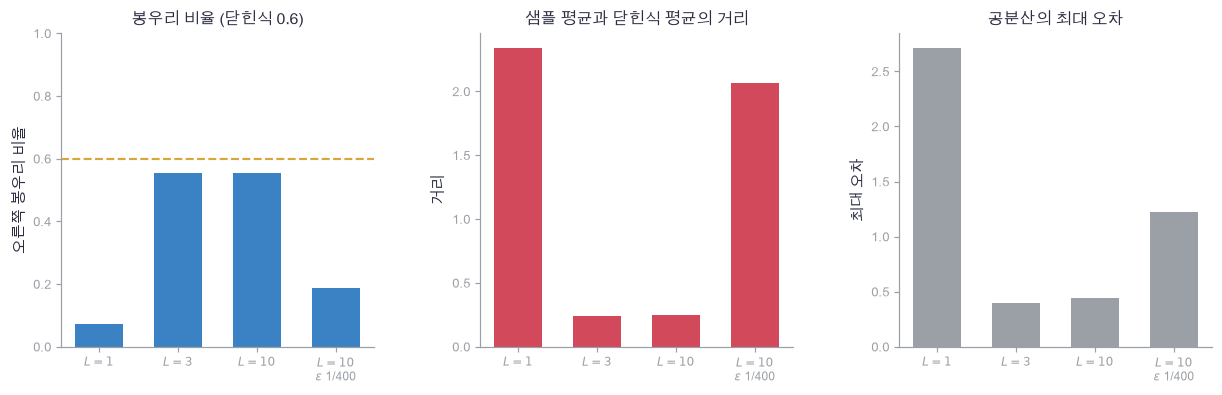

In [65]:
plot_variant_bars(variant_names, variant_fracs, variant_distances, variant_errors)

🔍 **확인** · $L=1$(사다리 없이 $\sigma_L$ 하나로 1,000걸음)은 오른쪽 봉우리를 거의 찾지 못하고 평균이 닫힌식에서 2 넘게 떨어집니다. $L=3$만 되어도 두 봉우리를 모두 채우고, $L=10$과 거의 같습니다. **첫 수준이 충분히 크기만 하면** 출발점을 잊게 만드는 일은 거기서 이미 끝나기 때문입니다. 이 예제의 봉우리 두 개는 $\sigma=3$ 하나로 이어지므로 중간 수준을 늘려도 얻는 것이 적습니다. 실제 이미지처럼 구조가 여러 겹인 데이터에서는 수준을 촘촘히 두어야 앞 수준의 결과가 다음 수준의 좋은 출발점이 됩니다.

$\epsilon$을 1/400로 줄이면(마지막 막대) 사다리가 있어도 소용이 없습니다. 걸음이 너무 짧아 가장 큰 수준에서도 출발점을 벗어나지 못하고, 결국 왼쪽 봉우리 근처에 그대로 남습니다. 2절에서 본 "$\alpha$가 작으면 정확하지만 느리다"가 사다리 위에서도 그대로 나타납니다.

### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** 작은 $\sigma$ 하나로는 왜 안 되고 큰 $\sigma$ 하나로도 왜 안 되는지, 그래서 사다리를 왜 큰 쪽에서 작은 쪽으로 내려오는지 말할 수 있나요? → 1·2절
- **수식:** 사다리의 기하 수열, $\sigma^2$ 가중 손실 $\mathbb E\|\sigma s_\theta+\epsilon\|^2$이 왜 모든 수준을 같은 크기로 만드는지, 걸음 크기 $\alpha_i=\epsilon\sigma_i^2/\sigma_L^2$이 왜 $\sigma_i^2$에 비례하는지 쓸 수 있나요? → 1·3·4절
- **구현:** 조건 입력 $\log\sigma$를 이어 붙이고 출력을 $\sigma$로 나누는 forward와 그 backward를 직접 쓰고 gradcheck를 통과시킬 수 있나요? annealed Langevin의 두 겹 반복문을 쓸 수 있나요? → 3·4절
- **변형:** $L$과 $\epsilon$을 바꾸면 봉우리 비율과 평균·공분산이 어떻게 달라지는지, 단일 $\sigma$ Langevin이 왜 한 봉우리에 갇히는지 설명할 수 있나요? → 2·4절

다음은 [34 diffusion 전방 과정](34_diffusion_forward.ipynb)입니다. 이 노트북의 $\sigma$ 사다리를 "시간 $t$에 따라 데이터를 조금씩 지우는 과정"으로 바꾸어 쓰고, 잡음 $\epsilon$을 맞히는 신경망과 score의 관계를 정리합니다.

📎 [Song·Ermon 2019](https://arxiv.org/abs/1907.05600)가 이 노트북의 NCSN과 annealed Langevin을 처음 제안한 원논문이고, [Song·Ermon 2020](https://arxiv.org/abs/2006.09011)이 $\sigma_{\max}$를 최대 쌍 거리로 잡는 규칙과 사다리 간격·걸음 크기의 선택을 정리했습니다. 이 노트북의 혼합 예제와 MNIST 좌표 모델은 설명을 위해 새로 구성한 것이며 원논문의 재현 실험이 아닙니다.